# Optimising for CAGR over the narrowed high-return region

[NB89](89-opt-sortino-leg-150k-realist-capital-masked.ipynb) searched the masked universe with
`optimise_sharpe` and returned a winner at **20.27% CAGR**. Mapping its CAGR surface afterwards
found a distinct higher-return region the Sharpe objective ranked only 11th to 14th:

| Region | `cagr_weight` | Vaults | Sortino window | CAGR | Max DD | Sharpe |
|---|---:|---:|---:|---:|---:|---:|
| NB89's winner ("plateau A") | 0.50 | 8 | 45 | 17.82-20.47% | -1.66 to -2.23% | 2.73-3.08 |
| **The high-CAGR region ("plateau B")** | **0.30** | **6** | **60** | **25.59-26.37%** | **-3.58%** | **2.09-2.22** |

Plateau B is the flattest thing this chain has found: three of four `gate_threshold` values sampled
at 360 / 0.30 / 6 vaults / 60 / 90 / `inverse_variance`, spanning **0.78 pp** of CAGR. Its worst
sampled one-axis neighbour is still 20.24%. But it was never the search's target - it is what the
Sharpe objective happened to walk past, with `gate_threshold` = -0.12 never evaluated.

This notebook searches for it directly, with `optimise_profit` (CAGR) as the objective.

**Based on** [89-opt-sortino-leg-150k-realist-capital-masked.ipynb](89-opt-sortino-leg-150k-realist-capital-masked.ipynb).
Realist Capital stays masked and Scared Money stays blacklisted, so results are directly comparable.

## The search space is cut from 3,840 to 216 combinations

NB89's marginal CAGR measurements identified two axes as cliffs rather than plateaus - one side is
simply wrong - and two more with dead outer values. Pinning and trimming those:

| Parameter | NB89 | NB90 | Why |
|---|---|---|---|
| `cagr_lookback_days` | {270, 360} | **360 pinned** | 270 means -21.02% CAGR, best only 2.16% |
| `weighting_method` | {`inverse_vol`, `inverse_variance`} | **`inverse_variance` pinned** | +9.62% against -6.73% mean; 87% consensus |
| `sharpe_lookback_days` | {30, 45, 60, 90, 120} | **{45, 60}** | outer three mean -6.00%, +1.67%, -14.10% |
| `inverse_vol_window` | {45, 60, 75, 90} | **{60, 75, 90}** | 45 is worst; 60 kept as the lower edge |
| `cagr_weight` | {0.3, 0.5, 0.7, 0.85} | **{0.3, 0.5, 0.7}** | 0.85 means -8.84%, the worst of four |
| `gate_threshold` | {-0.20, -0.16, -0.12, -0.08} | unchanged | the axis with the unsampled hole |
| `max_assets_in_portfolio` | {6, 7, 8} | unchanged | 6 favours CAGR, 8 favours Sharpe |

**This is the point of the exercise.** 18 iterations at batch size 6 is 108 evaluations, which was
3% of NB89's space and is **50% of this one**. Every result in this chain since NB85 has carried the
same caveat - that a 3% sample is heavily path-dependent, demonstrated when NB86's Calmar search
found a configuration NB85's Sharpe search had missed in the identical space. Half coverage is the
first time that caveat is materially answered.

Two values were kept deliberately against their measured means: `inverse_vol_window` = 60 and
`cagr_weight` = 0.70. A plateau claim needs its boundary inside the search, otherwise a flat result
is indistinguishable from a truncated axis.

## Optimising CAGR is deliberately exposure-seeking

`optimise_profit` maximises CAGR with **no risk term at all**. The library's own `optimise_calmar`
docstring names the failure mode: "optimising for Sharpe produces flat equity curves (the optimiser
avoids trading to minimise volatility) whilst optimising for CAGR produces excessive drawdowns
(growth at any cost)."

That is the expected outcome here, not an accident, and it is why NB86's diagnostics matter more in
this notebook than in any before it:

- **The drawdown and capacity screens carry the weight.** NB89 found the strategy's 33% pool cap
  binding on 36 of 94 entries. A CAGR objective has every incentive to push further into small
  vaults, so the entry-as-percentage-of-TVL analysis is the real result here, not the headline.
- **A rounding diagnostic is included**, as in NB86. `optimise_profit` reads `get_cagr()`, which
  QuantStats builds with `.round(2)` on a fraction - so the objective sees CAGR on a **1 percentage
  point grid** and cannot distinguish 20.27% from 20.47%. Whether that resolution is adequate is
  measured below rather than assumed.

## What we are looking for

- **Does the CAGR objective find plateau B?** If it lands on 0.30 / 6 vaults / 60-day Sortino, that
  region is confirmed as a genuine optimum rather than something the Sharpe search passed by.
- **What is at `gate_threshold` = -0.12?** The one unsampled hole in an otherwise flat row.
- **How much drawdown does growth-at-any-cost actually buy?**
- **Does the capacity profile degrade?** NB89's masked winner was the first in this chain whose
  largest contributor was capacity-clean (HLP at 0.02% of TVL).

## Key new insights and what did we learn from this experiment?

Mask verified: **0 positions on masked vaults, 0 on blacklisted vaults** across all 108 evaluations.
107 unique configurations of 216, **50% coverage**.

### Narrowing the space removed every bad configuration and every crash

| | NB89 (3,840 combinations, 3% sampled) | NB90 (216 combinations, 50% sampled) |
|---|---|---|
| CAGR range | **-38.94%** to 26.37% | **+0.11%** to 27.79% |
| Median CAGR | 7.53% | **16.79%** |
| Crashed configurations | 3 | **0** |
| Destroyed or stranded capital | none | none |

**Not one configuration in the narrowed space loses money.** The two pinned axes were carrying the
entire loss-making region: `cagr_lookback_days` = 270 and `weighting_method` = `inverse_vol`. This
is the strongest evidence so far that those two are genuine cliffs rather than sampling artefacts -
NB89 could only measure them as marginal means, and this run shows that removing them leaves nothing
bad behind.

The three crashes NB89 hit at `sharpe_lookback_days` = 90 also vanished, because that value is
outside the narrowed space.

### The rounding objection to a CAGR objective does not survive measurement

`optimise_profit` reads `get_cagr()`, which QuantStats rounds to a 1 percentage point grid:

| | |
|---|---|
| Distinct CAGR values the objective saw | **27** of 107 configurations |
| Spearman rank correlation, objective vs recomputed CAGR | **0.998** |
| Configurations tied at the objective's best value | **1** (no tie) |
| Objective's winner, ranked on recomputed CAGR | **1 of 107** |

The objective picked the true optimum outright. This is the same outcome NB86 measured for Calmar,
and for the same reason: a real search spans a wide enough range that a 1 pp grid still separates it.

### Plateau B is confirmed, complete, and flat across all four gate values

The hole filled in at 25.72%, right in the middle of its neighbours. At 0.30 / 6 vaults / 60-day
Sortino, CAGR by gate and volatility window:

| CAGR | gate -0.20 | -0.16 | -0.12 | -0.08 |
|---|---:|---:|---:|---:|
| vol 60 | · | 22.72% | 22.76% | · |
| vol 75 | 24.45% | · | · | 23.00% |
| **vol 90** | **26.37%** | **25.59%** | **25.72%** | **26.19%** |

**0.78 pp of spread across the complete gate axis**, and every sampled point in the whole 4x3
sub-grid stays above 22.7%. This is the flattest high-return region this chain has found, and it is
now verified rather than inferred.

### But the CAGR objective's winner is not in it - and it is a ridge, not a plateau

The search returned **27.79%** at 0.50 / -0.20 / vol 90 / **7 vaults** / 45-day Sortino, a
configuration in neither plateau A (0.50 / 8 / 45) nor plateau B (0.30 / 6 / 60). Its own gate row:

| CAGR | gate -0.20 | -0.16 | -0.12 | -0.08 |
|---|---:|---:|---:|---:|
| vol 90 | **27.79%** | 25.76% | 23.48% | **16.92%** |

**A monotone 10.87 pp decline across the gate axis**, against plateau B's 0.78 pp. The winner sits
at `gate_threshold` = -0.20, which is the **boundary of the searched range** - the CAGR objective
wants the most permissive gate available and would take more if offered.

That is the growth-at-any-cost failure mode the library's `optimise_calmar` docstring predicts,
appearing exactly where expected. The objective found a real optimum; it is a corner solution on a
slope.

### The winner buys 1.42 pp of CAGR with a much worse capacity profile

| Realised profit from entries above ... of the vault's TVL | NB89 Sharpe winner | Plateau B | **NB90 CAGR winner** |
|---|---:|---:|---:|
| 10% of TVL | 72.4% | 38.8% | **86.1%** |
| **20% of TVL** | **32.9%** | **30.8%** | **91.8%** |

The CAGR winner's largest contributor is **Goon Edging at 40.2% of realised profit**, entered at
$24,370 against a $66,521 vault - 33.0%, the `per_position_cap_of_pool_pct` cap binding exactly.
Octavious contributes 19.4% on $4,749 into a $12,590 vault. HLP, the one genuinely capacity-clean
holding, falls from 32.3% of profit in NB89 to 22.9%.

Plateau B is materially cleaner: its largest contributor is **pmalt at 38.6% of realised profit,
entered at 6.7% of a $264,150 vault**, with HLP at 20.3% and 0.0% of TVL. Two of its top three
contributors are capacity-clean.

**Plateau B returns 26.37% against the winner's 27.79% while taking roughly a third as much of its
profit from capacity-stretched positions.** For 1.42 pp of CAGR the objective's winner triples the
share of profit that fill-at-NAV is subsidising.

### The two are otherwise close, and the winner is better risk-adjusted

| | Plateau B | NB90 CAGR winner |
|---|---:|---:|
| CAGR | 26.37% | **27.79%** |
| Max drawdown | -3.58% | **-3.26%** |
| Sharpe | 2.10 | **2.57** |
| Sortino | 3.50 | **4.46** |
| Calmar | 7.36 | **8.52** |

The winner dominates plateau B on every risk metric as well as return. Its weaknesses are entirely
in the two dimensions the metrics table cannot see: parameter fragility and capacity.

### Against NB89's Sharpe winner, the trade is what theory predicts

| | NB89 Sharpe winner | NB90 CAGR winner |
|---|---:|---:|
| CAGR | 20.27% | **27.79%** |
| Volatility (ann.) | **6.03%** | 9.66% |
| Max drawdown | **-1.66%** | -3.26% |
| Sharpe | **3.08** | 2.57 |
| Calmar | **12.24** | 8.52 |
| Position win rate | **30.23%** | 23.86% |
| Time in market | 49.0% | 49.0% |

+7.52 pp of CAGR for 1.6 pp more drawdown and 3.6 pp more volatility. Both hold exactly 49.0% time
in market, so this is not a deployment difference - it is the same book taken at different
concentration.

## Summary of results

**Best configuration by CAGR: `cagr_weight` 0.50, `gate_threshold` -0.20, 90-day volatility window,
7 vaults, 45-day Sortino window** (with 360-day CAGR lookback and `inverse_variance` pinned).
27.79% CAGR, -3.26% max drawdown, Sharpe 2.57, Sortino 4.46, Calmar 8.52, 478 trades, 88 positions,
$170,024 final equity.

**Narrowing 3,840 combinations to 216 eliminated every losing configuration and every crash.** The
worst result in the space is +0.11% and the median is 16.79%, against -38.94% and 7.53% in NB89.

**Plateau B is confirmed and complete**: 25.59-26.37% across all four gate values at 0.30 / 6 vaults
/ 60-day Sortino / vol 90, a 0.78 pp spread, with the previously unsampled -0.12 landing at 25.72%.

**The CAGR objective's winner is a ridge, not a plateau** - it falls 10.87 pp moving the gate one
step and sits on the boundary of the searched range.

**Recommendation: plateau B is the better configuration despite returning 1.42 pp less.** It is flat
where the winner is steep, and takes 30.8% of its profit from entries above 20% of a vault's TVL
against the winner's 91.8%.

**A 1 pp rounding grid is adequate for a CAGR objective in this universe** - 27 distinct values,
Spearman 0.998, winner correct and untied.

## Robustness of results

- **The best day is one vault, not a market move.** Both configurations peak on **2026-06-26**
  (+2.57% and +3.35%) while BTC moved only **+0.51%**. The driver is **Goon Edging +7.90%** on that
  day, held at $29,870 - 33.0% of its $66,521 TVL. This is the opposite of NB89, whose best day
  coincided with BTC +2.30% and was legitimate. A single capacity-capped position produces the
  largest daily gain in both books here.
- **Both still fail the top-trade removal test, and plateau B fails it harder.** The five largest
  positions are 117.1% of net realised profit for the winner and 108.5% for plateau B. Removing the
  best 5 days of 188 takes the winner from 13.46% to 2.49% and **plateau B from 12.81% to -0.01%** -
  plateau B's entire return is in five days. Flatness in parameter space is not flatness in time.
- **Kurtosis remains extreme** at 11.99 (winner) and 12.10 (plateau B), essentially unchanged from
  NB89's 12.79. Narrowing the parameter space did nothing for return distribution shape, which it
  had no reason to.
- **The gate optimum is pressed against the edge of the searched range.** -0.20 is the most
  permissive value available and the CAGR objective chose it. The true optimum may lie beyond, and
  the axis should be extended before this winner is trusted. Plateau B does not have this problem:
  it is flat across the whole range, so the boundary does not bind.
- **50% coverage is a real improvement but is not exhaustive.** 107 of 216 combinations ran. The
  plateau B sub-grid is 8 of 12 sampled; plateau C is 6 of 12. A full 216-combination grid search
  would now be affordable and would remove the sampling caveat entirely - that is the obvious next
  step and is cheaper than any search in this chain so far.
- **The narrowing is derived from NB89's marginal means, which came from a 3% sample.** Pinning
  `cagr_lookback_days` and `weighting_method` is well-evidenced (100% and 87% consensus, plus
  matched-pair tests), but `cagr_weight` = 0.85 and `sharpe_lookback_days` in {30, 90, 120} were
  dropped on marginal means alone. If those axes interact with the narrowed region, the exclusion
  would not show up here.
- **Two boundary values were kept deliberately and both earned their place.** `inverse_vol_window` =
  60 falls to 22.7% inside plateau B against 26.37% at 90, and `cagr_weight` = 0.70 has the worst
  mean of the three at 12.01%. Both confirm the axes are bounded rather than truncated.
- **The 33% pool cap is still the chain's largest unexamined assumption**, and this notebook makes
  the case sharper rather than resolving it. A CAGR objective pushes straight into it: 47 of 95
  entries above 20% of vault TVL. A pool-cap variant remains outstanding.
- **Realist Capital masked, Scared Money blacklisted**, one window 2026-01-01 to 2026-07-10, on a
  feed that is weekly before 2026-01-17. The mask is scoped to this experiment and must not
  propagate.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the CAGR-objective variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- **Pinned**: `max_concentration_pct = 0.35`, `max_assets_in_portfolio = 6`, 10 BPS exit fee.
- The engine steps every 12 hours, so `rebalance_every_n_cycles` counts **12-hour cycles**:
  1 = 12h, 2 = 24h, 3 = 36h, 4 = 48h, 5 = 60h, 6 = 72h.
- **Searched**: `rebalance_every_n_cycles` (1-6), `minimum_hold_days` (1-4) and
  `sell_rebalance_min_threshold_usd` (5 / 50 / 125 / 250 USD).
- Hold values above 4 days and the 25 USD softband were dropped: NB63 measured both as
  monotonically worse or indistinguishable, and the space is better spent on cadence resolution.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from skopt.space import Categorical

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '90-opt-cagr-plateau-b-realist-capital-masked'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Native 2-day rebalance cadence. NB63, NB64 and NB65 all settled on 48 hours, and NB65
    #: verified a native `cycle_2d` reproduces NB64's modulo-counter version to within 0.36 pp, so
    #: the cadence is pinned here rather than searched and the modulo counter is retired.
    #:
    #: Relies on the trade-executor fix that makes `perform_optimisation()` forward
    #: `cycle_duration`; without it the optimiser silently reverts to a daily clock.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: **Searched.** NB68 found 6 best on CAGR and 8 best on Sharpe/Calmar/drawdown at 150,000,
    #: with a reproducible hole at 7 - so the axis is not monotone and the optimum depends on the
    #: objective. Searched jointly here rather than settled by eye.
    max_assets_in_portfolio = Categorical([6, 7, 8])
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: **Searched.** The one parameter known to reverse with capital: NB65 measured 33% > 50% at
    #: 25,000, NB68 measured 50% > 33% at 150,000. At large size the ceiling stops being risk
    #: control and becomes a deployment constraint.
    max_concentration_pct = 0.33
    #: **Searched.** The best-evidenced lever in the chain: NB67 measured 15% -> 25% as worth
    #: +4.61 pp at 75,000 and +20.34 pp at 150,000, and NB68 confirmed a gain in all six
    #: combinations tested. 0.30 extends past anything measured so far.
    per_position_cap_of_pool_pct = 0.33
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Retired: the cadence is now the engine's own 2-day cycle, so every cycle acts.
    rebalance_every_n_cycles = 1
    #: Retired from the search: NB63 and NB64 both found it inert at or below the cadence and
    #: harmful above it, and NB69/NB70 confirmed no configuration wanted it.
    minimum_hold_days = 1

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: **Searched.** Sell-side softband in USD at a 150,000 bankroll: the $5 hard floor plus
    #: 0.25%, 0.5% and 1.0% of capital.
    #:
    #: The ladder stops at 1%. NB66 established the crash boundary is a fraction of capital -
    #: between 1% and 2% at every bankroll tested - because suppressed sells are not deducted from
    #: the buy budget, so a wide band lets the plan spend proceeds from a trim it then cancels.
    #: NB67 confirmed $3,000 (2%) and $6,000 (4%) both fail at 150,000 while $1,500 (1%) survives.
    #: 1% is the edge rather than a safe margin, so any crash at that rung is surfaced below
    #: instead of being scored as a zero.
    sell_rebalance_min_threshold_usd = 750.0

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: **Pinned, was searched.** NB89 measured 270 at a **-21.02% mean CAGR with a best of
    #: 2.16%**, against 360 at +12.46% mean and 26.37% best, and 360 took 100% consensus in the top
    #: 15 of both NB85 and NB89. This is a cliff rather than a plateau - one side is simply wrong -
    #: so pinning it halves the search space at no cost in coverage of anything good.
    #:
    #: NB84 traced the magnitude of the 360-day cliff to entry timing on Realist Capital. NB89
    #: masked that vault and the preference survived intact, so the axis is not a vault artefact.
    cagr_lookback_days = 360
    #: **Searched, narrowed to the interior plateau.** NB89's mean CAGR by value: 30 -> -6.00%,
    #: 45 -> +10.72%, 60 -> +11.06%, 90 -> +1.67%, 120 -> -14.10%. 45 and 60 are a genuine interior
    #: plateau with sharp falloff on both sides, so the outer three values are dropped. Both
    #: survivors are kept because they separate the two regions this notebook is comparing: NB89's
    #: Sharpe winner used 45, plateau B uses 60.
    sharpe_lookback_days = Categorical([45, 60])
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    #:
    #: **Narrowed.** 0.85 dropped: NB89 measured it at -8.84% mean CAGR, the worst of the four.
    #: 0.70 is kept despite a weak +4.88% mean, as the upper edge - a plateau claim needs its
    #: boundary inside the search or a flat result cannot be told from a truncated axis.
    cagr_weight = Categorical([0.3, 0.5, 0.7])
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = Categorical([-0.20, -0.16, -0.12, -0.08])
    #: **Searched.** The window for the volatility estimate that becomes the sizing weight.
    #:
    #: NB70 found a broad 45-60 day plateau with sharp falloff either side and no reason to move
    #: off 60 on its own - but it also found the exponent and the window are separate levers, and
    #: the window was last searched (NB28/NB29) on data that was 41% forward-filled. It is in the
    #: search because it interacts with everything else here, not because 60 looked wrong.
    #:
    #: This is an **indicator** parameter. `prepare_grid_combinations()` calls
    #: `create_indicators()` with each combination's own parameters, so every value gets its own
    #: indicator series - unlike a hand-built grid, where reusing a precomputed indicator set
    #: would silently give every cell the same 60-day series.
    #: **Narrowed.** NB89's mean CAGR by value: 45 -> +1.75%, 60 -> +5.40%, 75 -> +6.37%,
    #: 90 -> +3.07%, with the two best results in the whole search at 90 (26.37%) and 75 (23.89%).
    #: 45 is dropped. 60 is kept as the lower edge: inside plateau B it falls to 19.85% against
    #: 26.37% at 90, and that falloff is what makes the plateau claim testable.
    inverse_vol_window = Categorical([60, 75, 90])

    #: Pinned: size by 1/sigma^2 rather than 1/sigma. NB72 measured +2.77 pp of CAGR at 60 days,
    #: winning at 7 of 7 lookbacks on both the full window and clean daily data, with a genuine
    #: interior optimum at k=2. Note the gain is return-only - Sharpe moved +0.02 and drawdown
    #: 0.57 pp worse - so this pins the return-maximising choice, and the search below optimises
    #: Sharpe, which will not reward it for that.
    #: Selection score. ``cagr_sortino_weight`` replaces the Sharpe leg of the incumbent composite
    #: with Sortino, which is the change NB79 measured at +0.869 Sharpe on a single configuration.
    #: This notebook exists to find out whether that survives a search.
    selection_score_indicator = 'cagr_sortino_weight'

    #: **Pinned, was searched.** NB89 measured `inverse_variance` at +9.62% mean CAGR against
    #: `inverse_vol` at -6.73%, found it winning a matched pair on every metric (20.02% / Sharpe
    #: 2.98 against 19.72% / 2.59, identical on all six other axes), and its consensus *strengthened*
    #: to 87% of the top 15 once Realist Capital was masked.
    #:
    #: NB86 made the opposite choice its headline finding. NB87 showed the flip was worth 3 of 34
    #: percentage points, and NB88 showed it reversed sign under the mask - the preference was the
    #: single vault, not the sizing rule. Pinning it here halves the space again.
    weighting_method = 'inverse_variance'


    #: Unused while :py:attr:`weighting_method` is ``inverse_variance``; kept so the sizing helper
    #: has a value for every branch.
    weighting_exponent = 2.0
    softmax_temperature = 0.25

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Release-candidate bankroll.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Vault exit fee charged on every Hypercore redemption. Applied to the trading
    #: universe as a sell-side token tax, see the universe cell.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-07-10 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
cagr_lookback_days,360,int
cagr_weight,"Categorical(categories=(0.3, 0.5, 0.7), prior=...",Categorical
candle_time_bucket,TimeBucket.d1,TimeBucket
chain_id,999,ChainId


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

ARCHIVE = Path('/Users/moo/code/hl-vault-cached-backup')
DATASET_ROOT = Path('/tmp/nb63-hl-min-1000')


def prepare_dataset_root() -> Path:
    """Materialise the hl-min-1000 dataset in an isolated cache directory.

    Leaves the shared `~/.cache/tradingstrategy` untouched. The loader skips its HTTP HEAD
    check when the cached file is under 24h old, so the copies are refreshed only as they
    approach that bound - touching every run would change the indicator cache fingerprint
    and force a full recalculation.
    """
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    for src_path, dst_path in [
        (ARCHIVE / 'hl-min-1000' / 'vault-price-history.parquet', DATASET_ROOT / 'vault-price-history.parquet'),
        (ARCHIVE / 'hl-min-1000' / 'vault-universe.json', DATASET_ROOT / 'vault-universe.json'),
    ]:
        assert src_path.exists(), f'Dataset missing: {src_path}'
        if not dst_path.exists() or dst_path.stat().st_size != src_path.stat().st_size:
            shutil.copy2(src_path, dst_path)
        if time.time() - dst_path.stat().st_mtime > 12 * 3600:
            dst_path.touch()
    return DATASET_ROOT


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        vault_history_download_root=str(prepare_dataset_root()),
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_fee(universe, fee) -> int:
    """Charge a flat exit fee on the sell side of every vault pair.

    The backtest pricing model resolves a trade fee as ``pair.fee + directional token tax``.
    Vault pairs carry ``pair.fee == 0``, so a ``sell_tax`` on the vault share token makes the
    sell price ``share price x (1 - fee)`` while deposits stay at NAV.

    Mutating the universe here covers every optimiser combination: the mutated pair objects
    live in :py:attr:`TradingStrategyUniverse.pair_cache`, which is pickled to the worker
    processes along with the rest of the universe.
    """
    assert 0 <= fee < 0.10, f"Exit fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS exit fee to {fee_applied} vault pairs')


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 25b59fbf
Loaded 331 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur25b59fbf)


Loaded 331 vaults from remote vault metadata, source vaults count: 331


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 263.14it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,33 days 00:00:00,0.00,"12,784",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,33 days 00:00:00,0.00,"28,035",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,33 days 00:00:00,0.00,"65,250",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,33 days 00:00:00,0.00,"31,126",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,33 days 00:00:00,0.00,107,32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,33 days 00:00:00,0.00,"14,927",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,33 days 00:00:00,0.00,"150,636",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,33 days 00:00:00,0.00,579,32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,33 days 00:00:00,0.00,"7,422",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS exit fee to 331 vault pairs


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define()
def sortino_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sortino sub-score, the downside-aware counterpart of ``sharpe_score``.

    Identical to :py:func:`sharpe_score` except the denominator is downside deviation
    ``sqrt(mean(min(r, 0)^2))`` rather than total standard deviation.

    The motivation is NB78/NB79. The vaults responsible for most of the strategy's losses share a
    signature the Sharpe leg cannot see: they almost never post a down day, which inflates their
    trailing Sharpe rather than deflating it. NB78 measured the Sharpe leg as separating losers from
    winners at 0.038 - no better than chance. Sortino divides by downside only, so a series with no
    down days yields NaN and drops out of scoring instead of topping it.
    """
    lookback = int(sharpe_lookback_days)
    returns = close.pct_change()
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    downside = (returns.clip(upper=0.0) ** 2).rolling(lookback, min_periods=lookback).mean() ** 0.5
    sortino = (rolling_mean / downside.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sortino score``.

    Both sub-scores are bounded to ``[0, 1]``, so the blend is too. A vault must have enough history
    for both legs, and - unlike the Sharpe composite - must also have posted at least one down day
    inside the Sortino window, otherwise the Sortino leg is NaN and the vault goes unscored.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score",
        pair=pair,
        parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        "sortino_score",
        pair=pair,
        parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


display_indicators(indicators)


We have 12 indicators:


,Order,Source,Parameters,Dependencies
Name,,,,
cagr_score,1,close_price,cagr_lookback_days,
inverse_vol,1,close_price,inverse_vol_window,
return_gate,1,close_price,gate_lookback_days,
sharpe_score,1,close_price,sharpe_lookback_days,
sortino_score,1,close_price,sharpe_lookback_days,
trading_availability_criteria,1,strategy_universe,,
tvl,1,tvl,,
cagr_sharpe_weight,2,dependencies_only_per_pair,sharpe_lookback_days<br> cagr_lookback_days<br...,cagr_score<br> sharpe_score
cagr_sortino_weight,2,dependencies_only_per_pair,sharpe_lookback_days<br> cagr_lookback_days<br...,cagr_score<br> sortino_score


# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [7]:
import math


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


#: Vaults masked for this experiment only. **Not a blacklist.**
#:
#: A blacklist entry says a vault can never be traded. A mask says "run the counterfactual without
#: it and see what changes". The two are kept apart deliberately, because the reasons differ and
#: only one of them should propagate to other notebooks.
#:
#: Nothing here is a data-quality judgement. Anything masked below has a sound price series and
#: would be a legitimate holding; it is removed to measure how much of a result depends on it.
MASKED_VAULTS = {
    # Realist Capital - NB87 attributed 97.8% of the Calmar winner's advantage over the Sharpe
    # winner to this single vault, and NB88 confirmed causally that masking it costs the Calmar
    # configuration 35.87 pp of CAGR. Its data is sound: dense daily series, share price 2.11 to
    # 9.26 across 2026, TVL growing $109k to $484k as outside money chased the same run. Masked so
    # the search runs on a universe that does not contain this chain's recurring single answer.
    "0x77fee2df7bad4f1db93052fa82bf78eaab771a16",
}

#: Vaults excluded by hand because their price series cannot support a position.
#:
#: This is a data-quality exclusion, not a performance judgement. A vault belongs here when its
#: share price is small enough that the feed's precision, rather than the vault's trading, drives
#: the returns the strategy sees.
#:
#: Keyed on pool address rather than name: token symbols are truncated to ten characters in this
#: universe, so names are not unique and not stable.
MANUAL_BLACKLIST = {
    # Scared Money - share price 0.00000800 to 0.00005568 across 2026, one significant figure of
    # precision, moving +-20% a day on rounding rather than performance. NB84 traced ~6 pp of
    # NB80's headline CAGR to a $10,781 position taken against $28,654 of vault TVL (38% of the
    # vault) and exited at +89%, which the fill-at-NAV assumption makes free.
    "0x5290ab34acb59cfe1371baa5782eba14433d308f",
}

def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_cycles = int(parameters.rebalance_every_n_cycles)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # No modulo cadence: the engine's own cycle is 2 days, so every cycle rebalances.

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    #: Selection score indicator. Pinned to the Sortino composite for this notebook; the default
    #: keeps the function usable with the incumbent Sharpe composite.
    try:
        selection_score_indicator = parameters["selection_score_indicator"]
    except (KeyError, TypeError):
        selection_score_indicator = "cagr_sharpe_weight"
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Manually blacklisted: the price data is too broken to trade at the moment.
        if str(pair.pool_address).lower() in MANUAL_BLACKLIST:
            continue
        # Masked for this experiment only - see MASKED_VAULTS. Not a permanent exclusion.
        if str(pair.pool_address).lower() in MASKED_VAULTS:
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value(selection_score_indicator, pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the selected set so softmax and blend can normalise
    # across exactly the vaults that will be held.
    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(getattr(parameters, 'softmax_temperature', 0.25)),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
    )

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Weighting method: {parameters.weighting_method}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Optimiser

- Run optimiser

In [8]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The 'generic' unit for NumPy timedelta is deprecated.*",
    category=DeprecationWarning,
)

import logging
from tradeexecutor.backtest.optimiser import perform_optimisation
from tradeexecutor.backtest.optimiser import prepare_optimiser_parameters
from tradeexecutor.backtest.optimiser import MinTradeCountFilter
from tradeexecutor.backtest.optimiser_functions import optimise_profit, optimise_sharpe, optimise_calmar

# How many Gaussian Process iterations we do.
#
# 18 iterations at batch size 6 is 108 evaluations. The same budget covered 3% of NB85's and
# NB89's 3,840-combination space; against this notebook's 216 combinations it is **50% coverage**.
#
# That is the point of narrowing the space rather than a side effect. Every result in this chain
# since NB85 has carried the caveat that a 3% sample is heavily path-dependent, and NB86 proved it
# by finding, in the identical space with the identical budget, a configuration NB85's search had
# missed entirely. Half coverage is the first time that objection is materially answered.
#
# Nothing can be served from NB89's cache: the cache is keyed on `Parameters.id`, and pinning two
# axes changes the combination keys in any case.
iterations = 18

# What do we optimise for.
#
# Raw CAGR, with no risk term. `optimise_profit` returns `-get_cagr()`, so the Gaussian Process
# maximises annualised return and is indifferent to how much drawdown buys it.
#
# This is deliberately the opposite bias to NB85/NB89. The library's own `optimise_calmar` docstring
# states the trade directly: optimising Sharpe produces flat equity curves because the optimiser
# avoids trading to minimise volatility, while optimising CAGR produces excessive drawdowns. NB86
# demonstrated the first half in this universe - the Sharpe search selected the de-risked twin of a
# configuration returning twice as much. This notebook measures the second half.
#
# The consequence is that the drawdown, capacity and integrity screens below are load-bearing here
# in a way they were not before. A CAGR objective has every incentive to push deeper into small
# vaults where the 33% pool cap already binds.
search_func = optimise_profit
# search_func = optimise_sharpe
# search_func = optimise_calmar

optimiser_result = perform_optimisation(
    iterations=iterations,
    search_func=search_func,
    decide_trades=decide_trades,
    strategy_universe=strategy_universe,
    parameters=prepare_optimiser_parameters(Parameters),  # Handle scikit-optimise search space
    create_indicators=indicators.create_indicators,
    # A 7-day cadence leaves only ~27 rebalance cycles in the 2026 window, so the
    # original 50-trade floor would have filtered out exactly the slow-cadence
    # configurations this notebook exists to measure.
    result_filter=MinTradeCountFilter(20),
    timeout=150*60,    
    batch_size=6,
    # We are searching wacky parameter combinations and
    # some of them lead to buggy strategies,
    # by setting ignore_wallet_errors we just zero out buggy
    # strategies instead of crashing with an exception
    ignore_wallet_errors=True,  
    # Uncomment for diagnostics
    # log_level=logging.INFO,
    # max_workers=1,
)

print(f"Optimise completed, optimiser searched {optimiser_result.get_combination_count()} combinations, with {optimiser_result.get_cached_count()} results read directly from cache. and {optimiser_result.get_filtered_count()} filtered results.")

# Surface crashes rather than letting them rank silently.
#
# `ignore_wallet_errors=True` turns a failed backtest into a placeholder scored at the filtered
# value, so a configuration that *cannot run* is ranked last instead of being reported. That is how
# the $250 softband won NB63 and NB64 while being the one value that crashes every time. At this
# bankroll the 1% rung ($1,500) is the known edge, so any crash is expected to cluster there - and
# if it does not, something else is wrong.
failed = [r for r in optimiser_result.results if getattr(r.result, "exception", None) is not None]
print(f"Backtests failed with exception: {len(failed)}")
if failed:
    crash_df = pd.DataFrame([{
        **{p.name: p.value for p in r.result.combination.searchable_parameters},
        "exception": type(r.result.exception).__name__,
    } for r in failed]).drop_duplicates()
    display(crash_df.style.set_caption(
        "Configurations that could not complete a backtest - these are not 'bad', they are unrunnable"
    ))
    for column in crash_df.columns:
        if column == "exception":
            continue
        counts = crash_df[column].value_counts()
        if len(counts) == 1:
            print(f"  every crash has {column} = {counts.index[0]}")

Optimiser search result cache is /Users/moo/.cache/tradingstrategy/grid-search/90-opt-cagr-plateau-b-realist-capital-masked
Indicator cache is /Users/moo/.cache/indicators


Optimise completed, optimiser searched 108 combinations, with 108 results read directly from cache. and 0 filtered results.
Backtests failed with exception: 0


# Results

- Show the top results of all optimiser iterations in a single table

In [9]:
import math

from tradeexecutor.statistics.key_metric import (
    calculate_cagr, calculate_max_drawdown, calculate_sharpe, calculate_sortino,
)
from tradeexecutor.visual.equity_curve import resample_returns

filtered = [r for r in optimiser_result.results if r.filtered]
print(f"Filtering out {len(filtered)} results")

# Metrics are recomputed from each result's own return series rather than read from
# `GridSearchResult.get_cagr()` / `get_max_drawdown()`.
#
# Those accessors read `self.metrics`, which quantstats builds with `.round(2)`. Because the
# values are fractions, CAGR and max drawdown land on a **one percentage point grid**: every
# stored CAGR in this sweep is an exact multiple of 0.01. That quantisation manufactures ties -
# NB63's top five configurations all read "Calmar 4.86" from the rounded metrics while their
# true Calmars were 5.06, 5.10, 5.06, 5.13 and 5.07.
#
# It matters more here than in any previous notebook in this chain, because `optimise_profit` reads
# `get_cagr()` **directly**. The objective therefore cannot distinguish NB89's 20.27% winner from
# the 20.47% configuration one row below it: both read 0.20. The diagnostic at the end of this cell
# measures how many distinct values the objective actually saw and whether its ranking survives
# recomputation at full precision.
rows = []
failures = []
broken = []
screened = 0
for r in optimiser_result.results:
    if r.filtered:
        continue
    result = r.result
    if result.exception is not None:
        # `ignore_wallet_errors=True` converts a crashed backtest into a placeholder result whose
        # equity curve is indexed at 1970-01-01. Record it rather than scoring it.
        failures.append({
            **{param.name: param.value for param in result.combination.searchable_parameters},
            "exception": type(result.exception).__name__,
        })
        continue

    # `GridSearchResult.returns` is sampled once per **strategy cycle**, which is every 2
    # hours in this notebook. Resample to daily before annualising: quantstats computes Sharpe
    # and Sortino as sqrt(periods) x mean/std, so feeding 12h returns with periods=365 would
    # understate both by sqrt(2). CAGR (index-based) and max drawdown (path-based) are not
    # affected, but resampling puts every metric on the same daily basis the library itself
    # uses for `GridSearchResult.metrics`, and on the same basis as NB63.
    returns = resample_returns(result.returns.dropna(), "D")
    if not len(returns):
        continue

    # Integrity screen: destroyed and stranded capital.
    #
    # This notebook used to screen on the accounting identity
    # `final equity == initial cash + realised + unrealised`. After trade-executor #1623 that
    # identity holds **by construction**: realised + unrealised is now cash-flow profit, which
    # reduces to cash + holdings, which is equity. It cannot fail, so it screens nothing, and
    # "0 configurations failed the accounting check" was not evidence of anything.
    #
    # NB81 named the replacement, and it is the check that caught the genuine #1621 dust defect.
    # Two failure modes, both of which have really occurred in this chain and both of which the
    # identity is blind to:
    #
    # - **Destroyed**: a position funded with real cash that closes returning nothing. The capital
    #   enters the vault and never comes back, and equity still reconciles because the engine
    #   values the vanished position at zero.
    # - **Stranded**: a closed position still holding quantity. The books call it closed while
    #   value sits inside it.
    #
    # `ignore_wallet_errors=True` is what makes this screen necessary: it does not only hide
    # crashes, it lets a run with broken books continue to a complete, economically meaningless
    # equity curve.
    run_state = result.hydrate_state()
    run_portfolio = run_state.portfolio
    destroyed = 0
    stranded = 0
    for position in run_portfolio.get_all_positions():
        if position.is_open() or position.is_credit_supply():
            continue
        funded = sum(
            abs(float(t.executed_reserve or 0))
            for t in position.trades.values() if t.is_buy() and t.is_success()
        )
        returned = sum(
            abs(float(t.executed_reserve or 0))
            for t in position.trades.values() if t.is_sell() and t.is_success()
        )
        # $100 funded against $1 returned keeps ordinary engine dust out of the count.
        if funded > 100 and returned < 1.0:
            destroyed += 1
        if abs(float(position.get_quantity() or 0)) > 1e-9:
            stranded += 1

    screened += 1
    if destroyed or stranded:
        broken.append({
            **{param.name: param.value for param in result.combination.searchable_parameters},
            "destroyed positions": destroyed,
            "closed positions holding quantity": stranded,
        })
        continue

    params = {param.name: param.value for param in result.combination.searchable_parameters}
    cagr = float(calculate_cagr(returns))
    max_dd = float(calculate_max_drawdown(returns))
    rows.append({
        **params,
        "Trades": result.get_trade_count(),
        "CAGR": cagr,
        "Max DD": max_dd,
        "Sharpe": float(calculate_sharpe(returns, periods=365)),
        "Sortino": float(calculate_sortino(returns, periods=365)),
        "Calmar": cagr / abs(max_dd) if abs(max_dd) > 0 else float("nan"),
    })

if failures:
    print(f"{len(failures)} configuration(s) crashed and were excluded:")
    display(pd.DataFrame(failures))

if broken:
    print(f"{len(broken)} of {screened} configuration(s) DESTROYED OR STRANDED CAPITAL and were "
          f"excluded - positions funded with real cash that returned nothing, or closed positions "
          f"still holding quantity:")
    broken_df = pd.DataFrame(broken).sort_values("destroyed positions", ascending=False)
    display(broken_df)
    count_cols = ("destroyed positions", "closed positions holding quantity")
    for column in broken_df.columns:
        if column in count_cols:
            continue
        share = broken_df[column].value_counts(normalize=True)
        print(f"  {column}: most common value {share.index[0]} ({share.iloc[0]:.0%} of broken runs)")
else:
    print(f"No configuration destroyed or stranded capital across {screened} completed evaluations")

parameter_names_raw = [p.name for p in optimiser_result.results[0].result.combination.searchable_parameters]
raw = pd.DataFrame(rows)

# Cadence and minimum hold are pinned in this notebook (2-day engine cycle, no hold), so the
# derived cadence/effective-hold columns that NB63 and NB64 carried are gone. Every searched axis
# here is an allocation parameter.

# The Gaussian Process re-evaluates promising points, so the same combination can appear more
# than once. Duplicates would weight the per-lever means towards whatever the GP liked.
duplicates = len(raw) - len(raw.drop_duplicates(subset=parameter_names_raw))
if duplicates:
    print(f"Dropping {duplicates} duplicate evaluation(s) of combinations the optimiser revisited")
raw = raw.drop_duplicates(subset=parameter_names_raw, keep="first")

df = raw.set_index(parameter_names_raw).sort_values("CAGR", ascending=False)

degenerate = int(df["CAGR"].isna().sum())
if degenerate:
    print(f"Dropping a further {degenerate} configuration(s) with an undefined CAGR")
    df = df[df["CAGR"].notna()]

print(f"Showing {len(df)} unique configurations, best CAGR {df['CAGR'].iloc[0]:.2%}")

display(
    df.head(25).reset_index().style.format({
        "CAGR": "{:.2%}", "Max DD": "{:.2%}", "Sharpe": "{:.2f}",
        "Sortino": "{:.2f}", "Calmar": "{:.3f}", "Trades": "{:.0f}",
        }).background_gradient(subset=["CAGR"], cmap="RdYlGn")
    .set_caption("Top 25 unique configurations by CAGR, 10 BPS exit fee (metrics recomputed from returns)")
)

# Confirm both exclusions took effect: no position should exist on a blacklisted or masked vault in
# any run. A silent no-op on the mask would be indistinguishable from "masking changed nothing",
# which is one of the possible answers this notebook is testing for.
blacklisted_hits = 0
masked_hits = 0
for res in optimiser_result.results:
    if res.filtered or res.result.exception is not None:
        continue
    for position in res.result.hydrate_state().portfolio.get_all_positions():
        pool_address = str(position.pair.pool_address).lower()
        if pool_address in MANUAL_BLACKLIST:
            blacklisted_hits += 1
        if pool_address in MASKED_VAULTS:
            masked_hits += 1
print(f"Positions opened on blacklisted vaults across the whole search: {blacklisted_hits}")
print(f"Positions opened on masked vaults across the whole search: {masked_hits}")
assert blacklisted_hits == 0, "Blacklist did not take effect"
assert masked_hits == 0, "Mask did not take effect"


# Does the objective's own CAGR agree with CAGR recomputed from the return series?
#
# `optimise_profit` reads `get_cagr()` straight from the QuantStats metrics table, which is built
# with `.round(2)` on a **fraction** - so the objective sees CAGR on a 1 percentage point grid.
# NB86 ran the equivalent measurement for Calmar and found the objection to it did not survive
# contact with a real search. This is the same measurement for CAGR: how many distinct values did
# the objective have to work with, and does its ranking hold up at full precision?
from scipy.stats import spearmanr

rounded_rows = []
for res in optimiser_result.results:
    if res.filtered or res.result.exception is not None:
        continue
    cagr_rounded = res.result.get_cagr()
    if cagr_rounded is None or pd.isna(cagr_rounded):
        continue
    rounded_rows.append({
        **{p.name: p.value for p in res.result.combination.searchable_parameters},
        "objective CAGR": float(cagr_rounded),
    })

rounded_df = pd.DataFrame(rounded_rows).drop_duplicates(subset=parameter_names_raw)
rounded_df = rounded_df.set_index(parameter_names_raw)
joined = df.join(rounded_df, how="inner")

print()
print(f"CAGR rounding diagnostic over {len(joined)} configurations:")
print(f"  distinct CAGR values the objective saw: {joined['objective CAGR'].nunique()} "
      f"of {len(joined)} configurations")
print(f"  Spearman rank correlation, objective CAGR vs recomputed CAGR: "
      f"{spearmanr(joined['CAGR'], joined['objective CAGR']).statistic:.3f}")

# How many configurations are tied at the objective's top value, and how wide is the true spread
# inside that tie? This is the quantity that decides whether the winner was selected or drawn.
top_value = joined["objective CAGR"].max()
tied = joined[joined["objective CAGR"] == top_value]
print(f"  configurations tied at the objective's best value ({top_value:.2%}): {len(tied)}")
if len(tied) > 1:
    print(f"  true CAGR spread inside that tie: {tied['CAGR'].min():.2%} to {tied['CAGR'].max():.2%} "
          f"({(tied['CAGR'].max() - tied['CAGR'].min()) * 100:.2f} pp)")
best_by_objective = joined["objective CAGR"].idxmax()
rank = list(joined.sort_values("CAGR", ascending=False).index).index(best_by_objective) + 1
print(f"  objective's chosen winner ranks {rank} of {len(joined)} on recomputed CAGR")

Filtering out 0 results


No configuration destroyed or stranded capital across 108 completed evaluations
Dropping 1 duplicate evaluation(s) of combinations the optimiser revisited
Showing 107 unique configurations, best CAGR 27.79%


,cagr_weight,gate_threshold,inverse_vol_window,max_assets_in_portfolio,sharpe_lookback_days,Trades,CAGR,Max DD,Sharpe,Sortino,Calmar
0,0.500000,-0.200000,90,7,45,478,27.79%,-3.26%,2.57,4.46,8.522
1,0.300000,-0.200000,90,6,60,394,26.37%,-3.58%,2.10,3.50,7.359
2,0.300000,-0.080000,90,6,60,401,26.19%,-3.59%,2.22,3.57,7.300
3,0.500000,-0.160000,90,7,45,500,25.76%,-3.51%,2.45,4.19,7.332
4,0.300000,-0.120000,90,6,60,400,25.72%,-3.59%,2.10,3.46,7.163
5,0.300000,-0.160000,90,6,60,396,25.59%,-3.59%,2.09,3.45,7.123
6,0.500000,-0.080000,90,6,45,431,25.27%,-3.55%,2.17,3.51,7.117
7,0.300000,-0.200000,75,6,60,396,24.45%,-3.57%,2.00,3.31,6.846
8,0.500000,-0.200000,75,7,45,484,23.89%,-4.03%,2.30,3.78,5.932
9,0.500000,-0.120000,90,7,45,489,23.48%,-2.98%,2.39,3.93,7.889


Positions opened on blacklisted vaults across the whole search: 0
Positions opened on masked vaults across the whole search: 0

CAGR rounding diagnostic over 107 configurations:
  distinct CAGR values the objective saw: 27 of 107 configurations
  Spearman rank correlation, objective CAGR vs recomputed CAGR: 0.998
  configurations tied at the objective's best value (28.00%): 1
  objective's chosen winner ranks 1 of 107 on recomputed CAGR


## Standard optimiser result table

The presentation used across the optimiser notebooks, via `analyse_optimiser_result()` and
`render_grid_search_result_table()`.

**This table is not screened for destroyed capital.** The table above is - it excludes any
configuration that funded a position which closed returning nothing, or left quantity inside a
closed position. Where the two disagree, the screened one is authoritative. Both are shown because
the unscreened view is what the optimiser actually saw while choosing where to sample next, and
that is worth being able to inspect.


In [10]:
from tradeexecutor.analysis.optimiser import analyse_optimiser_result
from tradeexecutor.analysis.grid_search import render_grid_search_result_table

filtered_out = [r for r in optimiser_result.results if r.filtered]
print(f"Optimiser filtered out {len(filtered_out)} result(s) via result_filter")

# This used to be wrapped in try/except KeyError. `analyse_optimiser_result()` indexes every
# metric in the library's METRIC_REGISTRY, and quantstats does not emit `Expected Shortfall
# (cVaR)` for a degenerate returns series - which is exactly what the two crashed backtests in
# this search produce. Two rows out of 240 therefore took down the entire table. Fixed in
# trade-executor: a missing metric now reads NaN and renders as an empty cell.
standard_df = analyse_optimiser_result(
    optimiser_result,
    max_search_results=300,
    drop_duplicates=False,
)
print(f"Standard table: {len(standard_df)} results - NOT screened for destroyed capital")
render_grid_search_result_table(standard_df, extended_metrics=True)


Optimiser filtered out 0 result(s) via result_filter
Standard table: 108 results - NOT screened for destroyed capital


## Did the fee actually apply, and what did each lever do to turnover?

The optimiser pickles the universe to worker processes, so the first check is that the sell-side
tax survived that trip. The measurement compares each vault sell's executed price against the
vault's own daily close, which is independent of the two Hypercore sell paths.

Then, the point of the whole notebook: redemption volume and fees paid for the best configuration
versus the release-candidate baseline (daily cadence, no hold, $5 softband).

In [11]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        if candles is None or not len(candles):
            return float("nan")
        closes = candles.set_index("timestamp")["close"].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float("nan")


def turnover_report(grid_result, label: str) -> dict:
    """Sell-side turnover, fee paid and implied fee for one grid search result."""
    run_state = grid_result.hydrate_state()
    fee = Parameters.vault_redemption_fee
    exits = trims = 0
    exit_volume = trim_volume = 0.0
    implied = []
    for t in run_state.portfolio.get_all_trades():
        if not t.pair.is_vault() or not t.is_sell() or not t.is_success():
            continue
        value = abs(float(t.get_value() or 0.0))
        if t.closing:
            exits += 1
            exit_volume += value
        else:
            trims += 1
            trim_volume += value
        share_price = get_vault_share_price(t.pair, t.opened_at)
        if share_price == share_price:
            implied.append(1.0 - t.planned_price / share_price)
    volume = exit_volume + trim_volume
    implied_series = pd.Series(implied)
    days = (Parameters.backtest_end - Parameters.backtest_start).days
    return {
        "Configuration": label,
        "Vault sells": exits + trims,
        "Exits": exits,
        "Trims": trims,
        "Exit volume": exit_volume,
        "Trim volume": trim_volume,
        "Redemption volume": volume,
        "Turnover x capital": volume / Parameters.initial_cash,
        "Turnover x capital, annualised": volume / Parameters.initial_cash * 365 / days,
        "Fee paid": volume * fee / (1.0 - fee),
        "Median implied fee": float(implied_series.median()) if len(implied_series) else float("nan"),
        "Within 1 BPS of target": float((implied_series.sub(fee).abs() <= 0.0001).mean()) if len(implied_series) else float("nan"),
    }


def find_result(**params):
    """Locate the GridSearchResult for an exact parameter combination."""
    for r in optimiser_result.results:
        if r.filtered or r.result.exception is not None:
            continue
        combo = {p.name: p.value for p in r.result.combination.searchable_parameters}
        if all(combo.get(k) == v for k, v in params.items()):
            return r.result
    return None


# The winner, plus the best configuration using the *other* sizing rule as the reference.
# NB73 compared against its tightest pool cap; that dimension is pinned here, so the contrast that
# matters is the one this notebook added - inverse_vol against inverse_variance under a Sortino
# selection score, which NB71 and NB72 showed can reverse with the surrounding configuration.
best_params = dict(zip(df.index.names, df.index[0]))
best_result = find_result(**best_params)
reports = [turnover_report(best_result, f"Winner: {best_params.get('weighting_method', 'n/a')}")]

if "weighting_method" in df.index.names:
    winner_method = best_params.get("weighting_method")
    other = df[df.index.get_level_values("weighting_method") != winner_method]
    if len(other):
        other_params = dict(zip(df.index.names, other.index[0]))
        other_result = find_result(**other_params)
        if other_result is not None:
            reports.append(turnover_report(other_result, f"Best {other_params.get('weighting_method')}"))
    else:
        print("Only one sizing rule survived the integrity filter - no in-sweep contrast available")

turnover_df = pd.DataFrame(reports).set_index("Configuration")
display(turnover_df.T.style.format("{:,.4g}").set_caption(
    "Turnover and fees: winner versus the best daily-cadence configuration in this sweep"))

for label, row in turnover_df.iterrows():
    median_fee = row["Median implied fee"]
    within = row["Within 1 BPS of target"]
    target = Parameters.vault_redemption_fee
    print(f"{label}: median implied fee {median_fee:.3%} (target {target:.3%}), "
          f"{within:.1%} of sells within 1 BPS, turnover {row['Turnover x capital']:.1f}x "
          f"({row['Turnover x capital, annualised']:.1f}x annualised)")
    assert abs(median_fee - target) < 1e-5, (
        f"Exit fee did not survive the optimiser for {label}: median implied {median_fee:.4%}"
    )
print("Fee verified on every configuration inspected.")

# How the searched levers move outcomes. Deduplicated above, but the Gaussian Process still
# samples unevenly, so these marginals are confounded: cadence 1 was mostly explored with long
# holds (which are independently bad) and cadence 2 with short ones. The fixed-hold slice below
# is the one that isolates cadence.
sweep = df.reset_index()

#: Only dimensions that actually varied. NB73 hardcoded its own search space here, which breaks
#: the moment a parameter is pinned - as three of them are in this notebook.
SEARCHED = [n for n in df.index.names if n in sweep.columns and sweep[n].nunique() > 1]
print(f"Searched dimensions that varied: {SEARCHED}")

for lever in SEARCHED:
    grouped = sweep.groupby(lever).agg(
        configs=("CAGR", "size"),
        cagr=("CAGR", "mean"), max_dd=("Max DD", "mean"),
        sharpe=("Sharpe", "mean"), calmar=("Calmar", "mean"),
    )
    display(grouped.style.format({
        "cagr": "{:.2%}", "max_dd": "{:.2%}", "sharpe": "{:.2f}", "calmar": "{:.2f}",
    }).set_caption(
        f"Mean outcome by {lever}. The Gaussian Process samples unevenly, so these marginals are "
        f"confounded by whatever else it explored alongside each value - read them as a shortlist"
    ))

# The sizing rule crossed with basket size. This is the comparison NB71/NB72 disagreed about, so
# seeing whether it is stable under a Sortino selection score is the point of adding the dimension.
if {"weighting_method", "max_assets_in_portfolio"} <= set(SEARCHED):
    grouped = sweep.groupby(["weighting_method", "max_assets_in_portfolio"]).agg(
        configs=("CAGR", "size"), cagr=("CAGR", "mean"), max_dd=("Max DD", "mean"),
        sharpe=("Sharpe", "mean"), calmar=("Calmar", "mean"),
    )
    display(grouped.style.format({
        "cagr": "{:.2%}", "max_dd": "{:.2%}", "sharpe": "{:.2f}", "calmar": "{:.2f}",
    }).set_caption("Sizing rule crossed with basket size"))

# Best configuration found under each sizing rule, which the marginals above cannot show.
if "weighting_method" in SEARCHED:
    rows = []
    for method, group in sweep.groupby("weighting_method"):
        top = group.sort_values("Sharpe", ascending=False).iloc[0]
        rows.append({
            "Sizing rule": method, "Configs": len(group), "Best Sharpe": top["Sharpe"],
            "CAGR": top["CAGR"], "Max DD": top["Max DD"], "Calmar": top["Calmar"],
        })
    display(pd.DataFrame(rows).set_index("Sizing rule").style.format({
        "Best Sharpe": "{:.3f}", "CAGR": "{:.2%}", "Max DD": "{:.2%}", "Calmar": "{:.2f}",
    }).set_caption("Best configuration found under each sizing rule"))


Configuration,Winner: n/a
Vault sells,201
Exits,88
Trims,113
Exit volume,1.981e+06
Trim volume,7.936e+05
Redemption volume,2.775e+06
Turnover x capital,18.5
"Turnover x capital, annualised",35.53
Fee paid,"2,777"
Median implied fee,0.001


Winner: n/a: median implied fee 0.100% (target 0.100%), 62.7% of sells within 1 BPS, turnover 18.5x (35.5x annualised)
Fee verified on every configuration inspected.
Searched dimensions that varied: ['cagr_weight', 'gate_threshold', 'inverse_vol_window', 'max_assets_in_portfolio', 'sharpe_lookback_days']


,configs,cagr,max_dd,sharpe,calmar
cagr_weight,,,,,
0.300000,42,17.67%,-3.53%,1.85,5.53
0.500000,27,18.58%,-3.72%,1.96,5.80
0.700000,38,12.01%,-4.71%,1.02,2.95


,configs,cagr,max_dd,sharpe,calmar
gate_threshold,,,,,
-0.200000,26,18.39%,-3.87%,1.71,5.40
-0.160000,16,18.47%,-4.17%,1.64,4.70
-0.120000,33,14.87%,-3.95%,1.57,4.61
-0.080000,32,13.62%,-4.07%,1.47,4.17


,configs,cagr,max_dd,sharpe,calmar
inverse_vol_window,,,,,
60,38,13.88%,-4.38%,1.38,3.63
75,30,15.44%,-4.04%,1.50,4.43
90,39,18.20%,-3.59%,1.84,5.90


,configs,cagr,max_dd,sharpe,calmar
max_assets_in_portfolio,,,,,
6,40,19.28%,-4.04%,1.59,5.07
7,37,15.76%,-4.09%,1.60,4.39
8,30,11.53%,-3.82%,1.55,4.52


,configs,cagr,max_dd,sharpe,calmar
sharpe_lookback_days,,,,,
45,59,18.05%,-3.21%,1.90,6.10
60,48,13.23%,-4.97%,1.19,2.94


## Search stability check

Do the top configurations agree on their parameters, and how tight is the Calmar plateau? Read alongside the heatmaps, cluster analysis and parallel-coordinates plots below.

In [12]:
# Numeric stability: parameter consensus across the top configs by the search objective.
stab = df.reset_index().copy()
stab = stab.sort_values('CAGR', ascending=False)
param_cols = list(df.index.names)
TOPN = 15
top = stab.head(TOPN)

print(f"Parameter consensus across the top {TOPN} configs by CAGR:")
rows = []
for pc in param_cols:
    vc = top[pc].value_counts(normalize=True)
    rows.append({'parameter': pc, 'mode': vc.index[0], 'mode_share': round(float(vc.iloc[0]), 2), 'distinct_in_top': int(top[pc].nunique())})
display(pd.DataFrame(rows))

print(f"CAGR in top {TOPN}: {top['CAGR'].min():.2%} - {top['CAGR'].max():.2%}   (all {len(stab)}: {stab['CAGR'].min():.2%} - {stab['CAGR'].max():.2%})")
print(f"Sharpe across those same top {TOPN}: {top['Sharpe'].min():.2f} - {top['Sharpe'].max():.2f}, "
      f"max drawdown {top['Max DD'].min():.2%} - {top['Max DD'].max():.2%}")
print("A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.")


Parameter consensus across the top 15 configs by CAGR:


,parameter,mode,mode_share,distinct_in_top
0,cagr_weight,0.30,0.60,3
1,gate_threshold,-0.16,0.33,4
2,inverse_vol_window,90.00,0.53,3
3,max_assets_in_portfolio,6.00,0.73,2
4,sharpe_lookback_days,60.00,0.60,2


CAGR in top 15: 22.16% - 27.79%   (all 107: 0.11% - 27.79%)
Sharpe across those same top 15: 1.44 - 2.57, max drawdown -4.81% - -2.98%
A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.


## Equity curves

- Visualise equity curves of all grid search results in a single chart

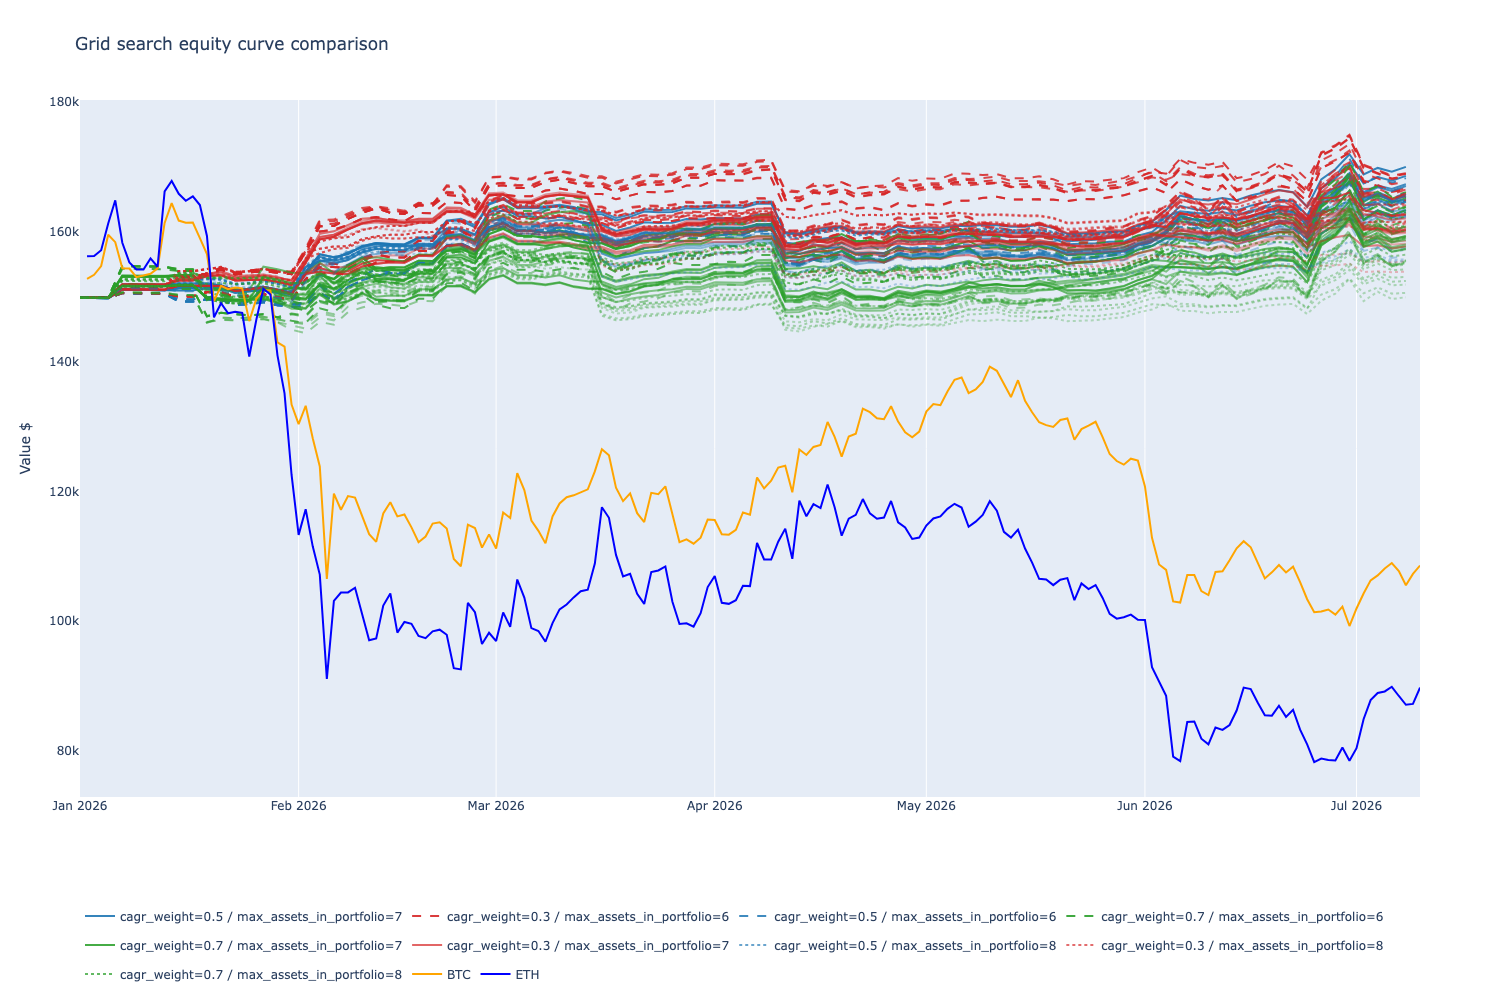

In [13]:
from tradeexecutor.visual.grid_search_basic import visualise_grid_search_equity_curves
from tradeexecutor.analysis.multi_asset_benchmark import get_benchmark_data

# Automatically create BTC and ETH buy and hold benchmark if present
# in the trading universe
benchmark_indexes = get_benchmark_data(
    strategy_universe,
    cumulative_with_initial_cash=Parameters.initial_cash,
    start_at=pd.Timestamp(Parameters.backtest_start),
)

# Extract GridSearchResult instances from optimiser results.
#
# `ignore_wallet_errors=True` turns a crashed backtest into a placeholder GridSearchResult whose
# equity curve is indexed at 1970-01-01/02 (see create_grid_search_failed_result). Those rows are
# not removed by `r.filtered`, which only reflects the MinTradeCountFilter, so leaving them in
# stretches the chart's x axis from 1970 to 2026 and flattens every real curve into a vertical line.
candidates = [r.result for r in optimiser_result.results if not r.filtered]
grid_search_results = [r for r in candidates if r.exception is None]
failed = len(candidates) - len(grid_search_results)
if failed:
    print(f"Excluding {failed} backtest(s) that failed with an exception from the equity curve chart")

fig = visualise_grid_search_equity_curves(
    grid_search_results,
    benchmark_indexes=benchmark_indexes,
    log_y=False,
    # Group by dimensions that actually varied in this search. `weighting_method` and
    # `cagr_lookback_days` are pinned in this notebook, so grouping on them raises
    # "No parameter". `cagr_weight` and basket size are the two axes that separate NB89's
    # plateau A (0.50 / 8 vaults) from the high-CAGR plateau B (0.30 / 6 vaults).
    group_by="cagr_weight",
    group_by_secondary="max_assets_in_portfolio",
)
fig.show()

# Parameter analysis

## Decision tree visualisation

Analysing CAGR for parameters: ['cagr_weight', 'gate_threshold', 'inverse_vol_window', 'max_assets_in_portfolio', 'sharpe_lookback_days']


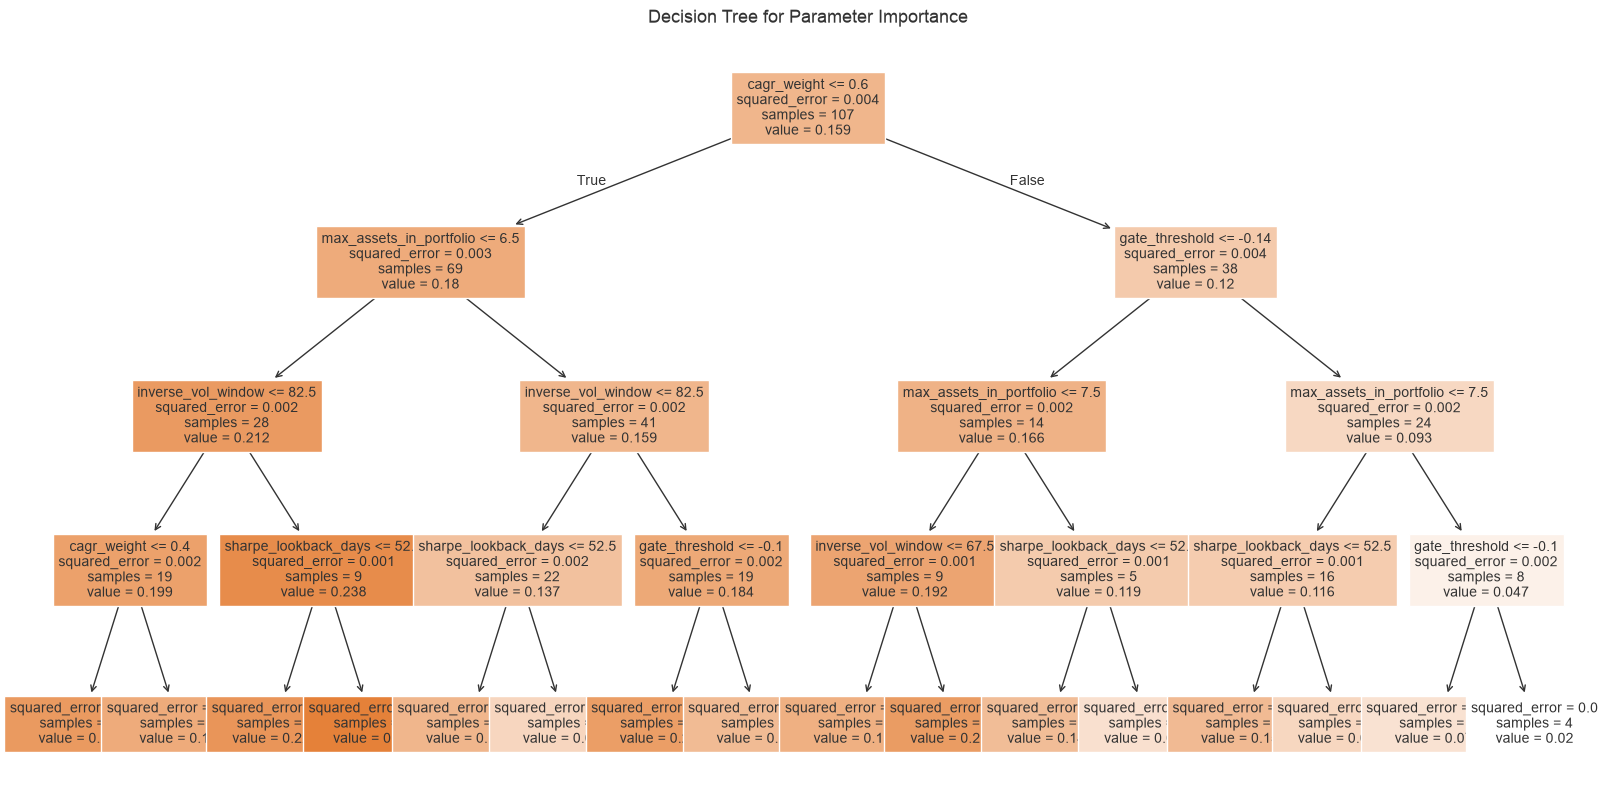

In [14]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree

parameter_names = list(df.index.names)
parameter_df = df
parameter_df = parameter_df.reset_index()

analysis_metric = "CAGR"
print(f"Analysing {analysis_metric} for parameters: {parameter_names}")

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a simple decision tree
tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X, y)

# Plot
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, filled=True, fontsize=10)
plt.title('Decision Tree for Parameter Importance')
plt.show()

## Feature importance analysis

Use a regression model to determine which parameters have the strongest influence.



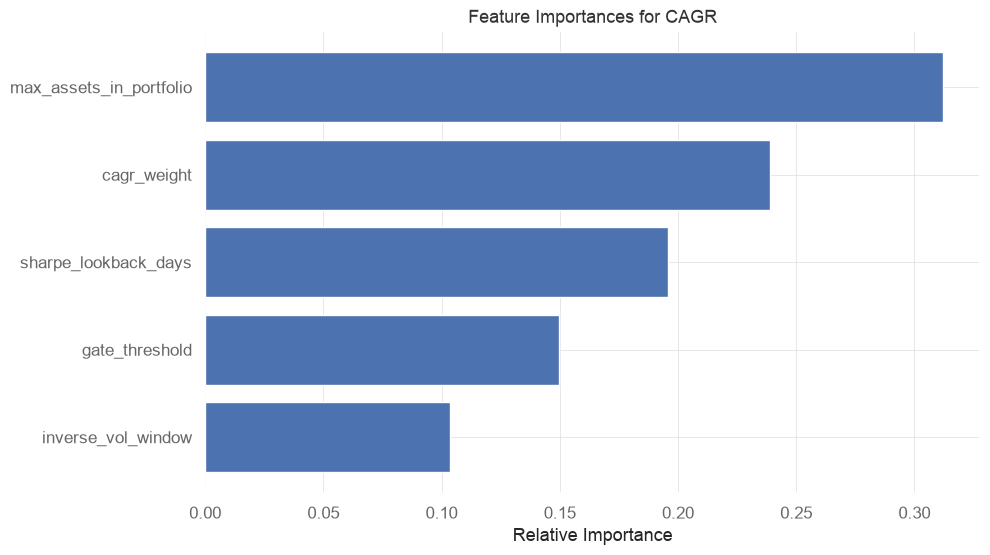

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values to numeric if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a random forest model
model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

# Plot feature importances
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title(f'Feature Importances for {analysis_metric}')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Heatmaps for parameter pairs

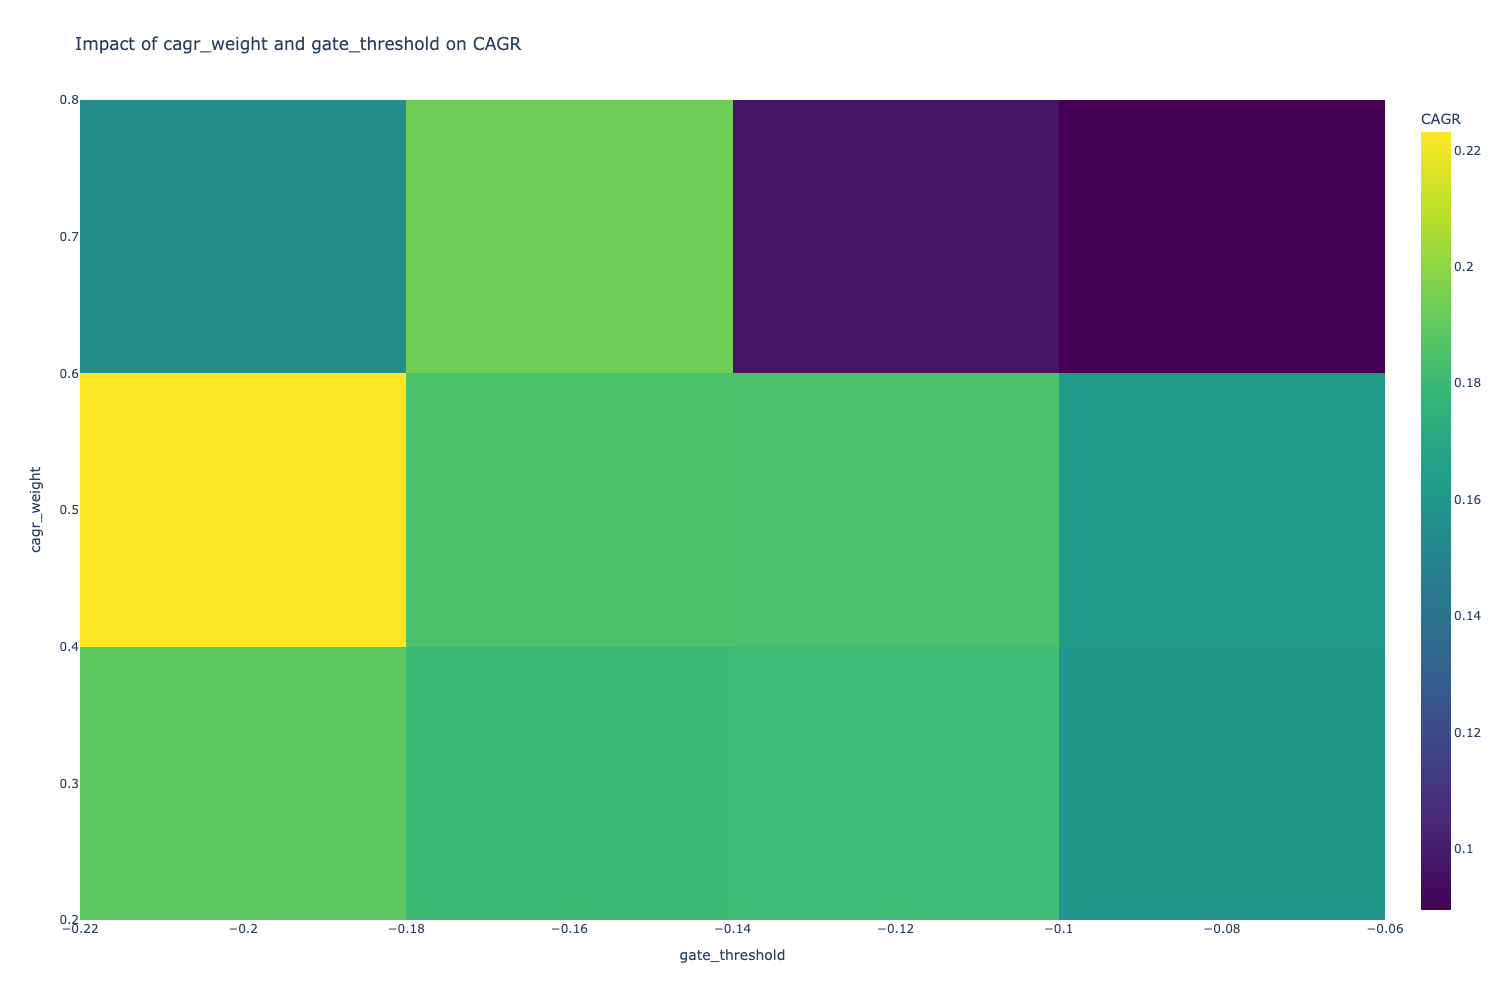

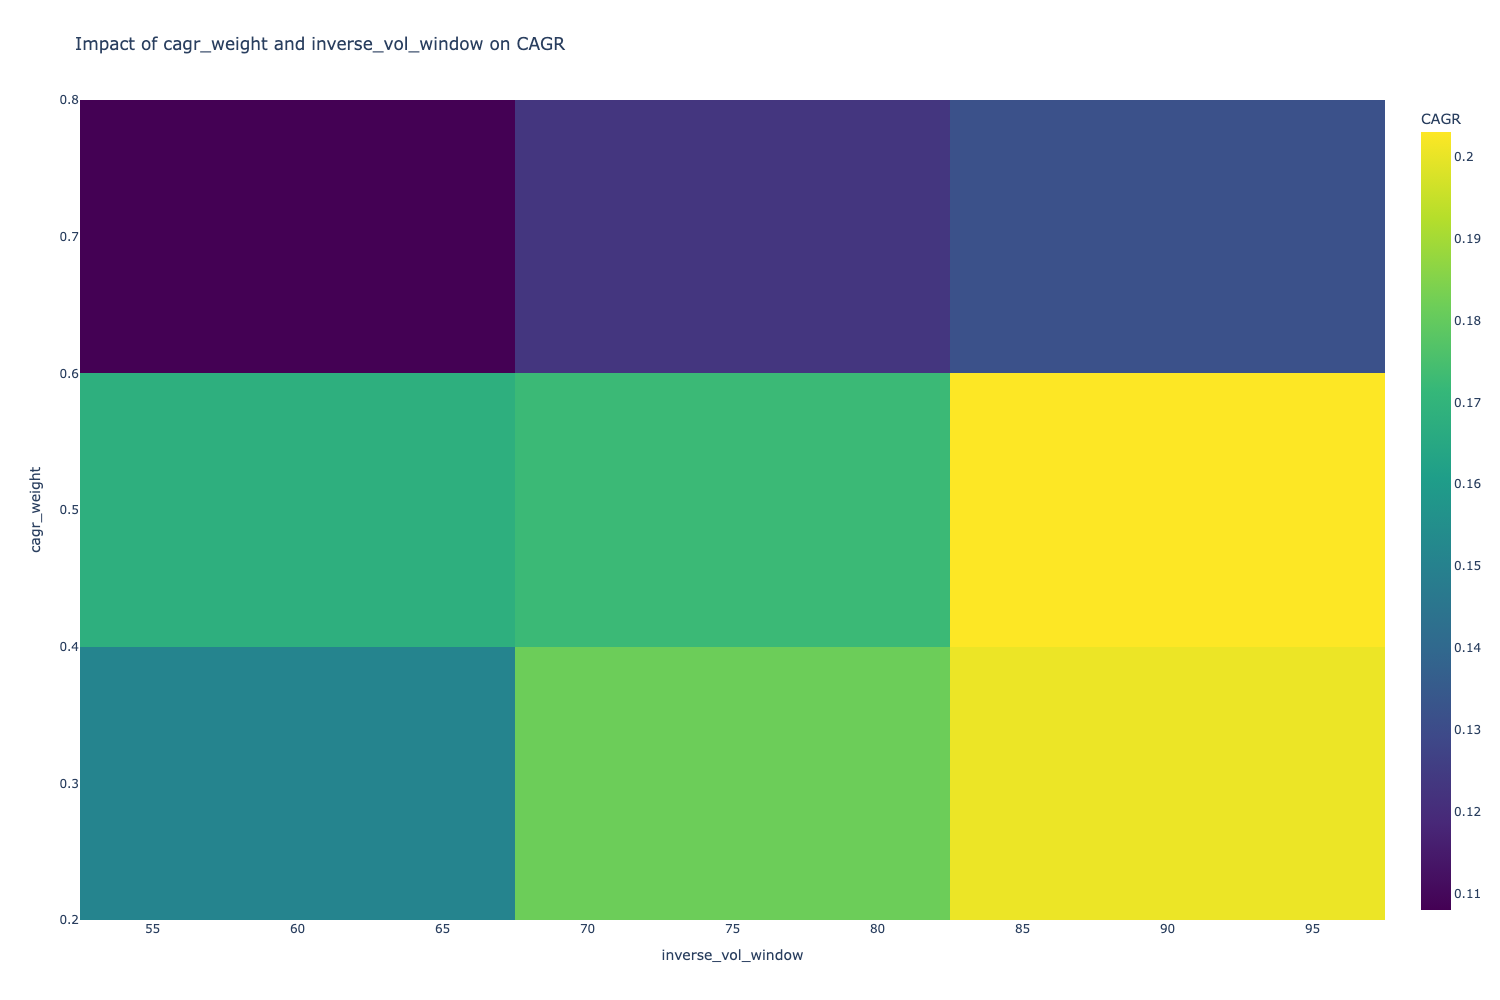

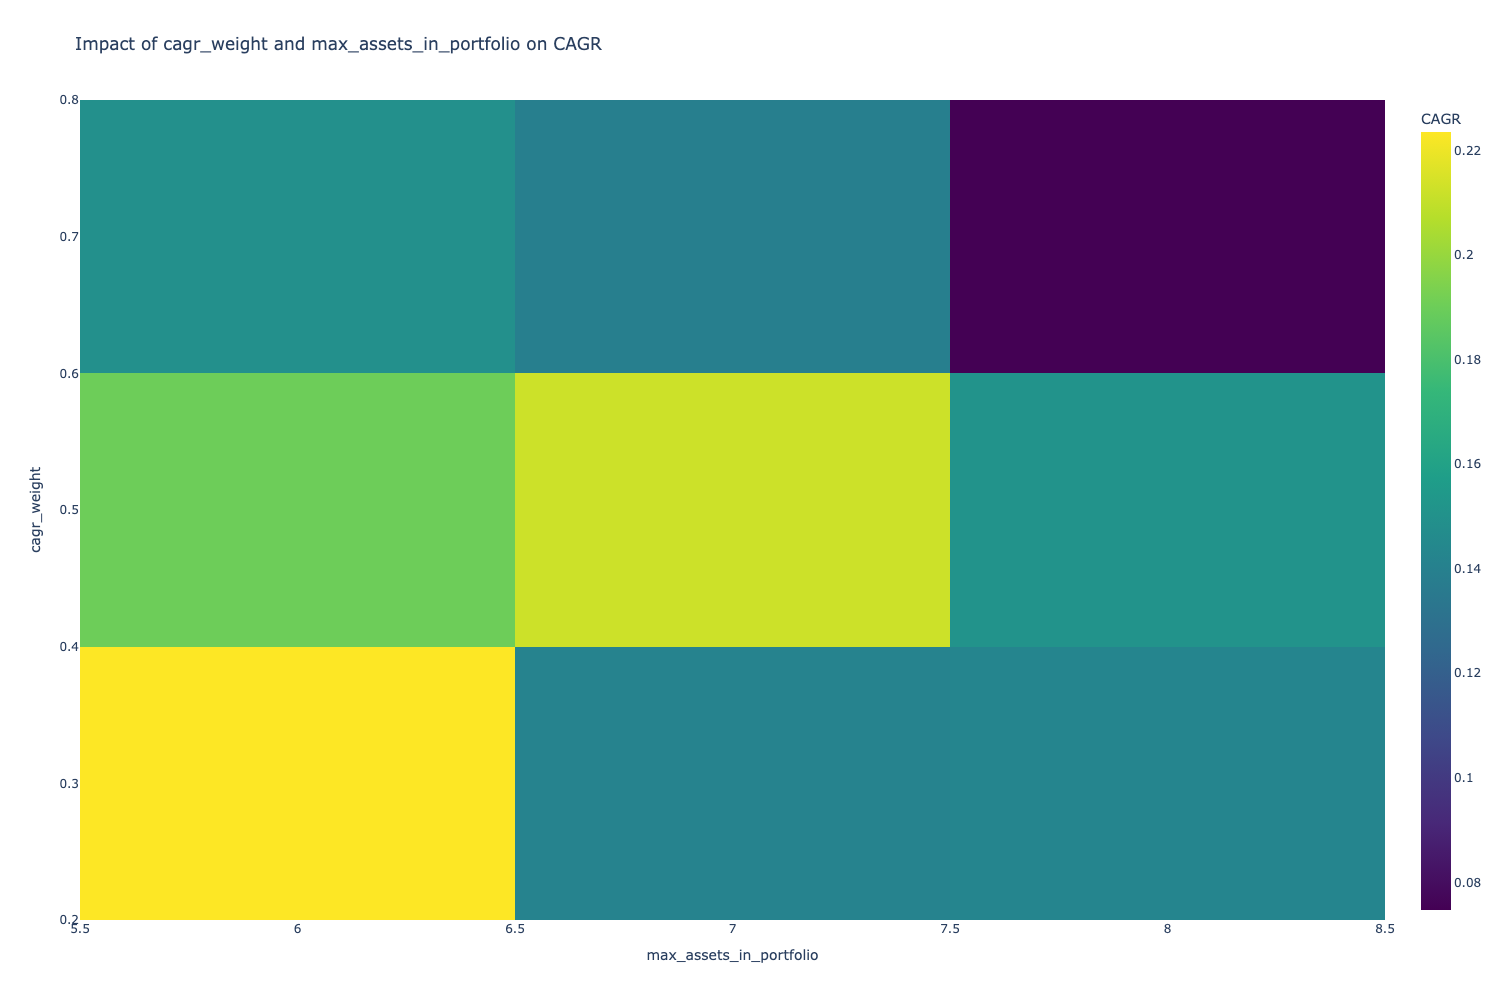

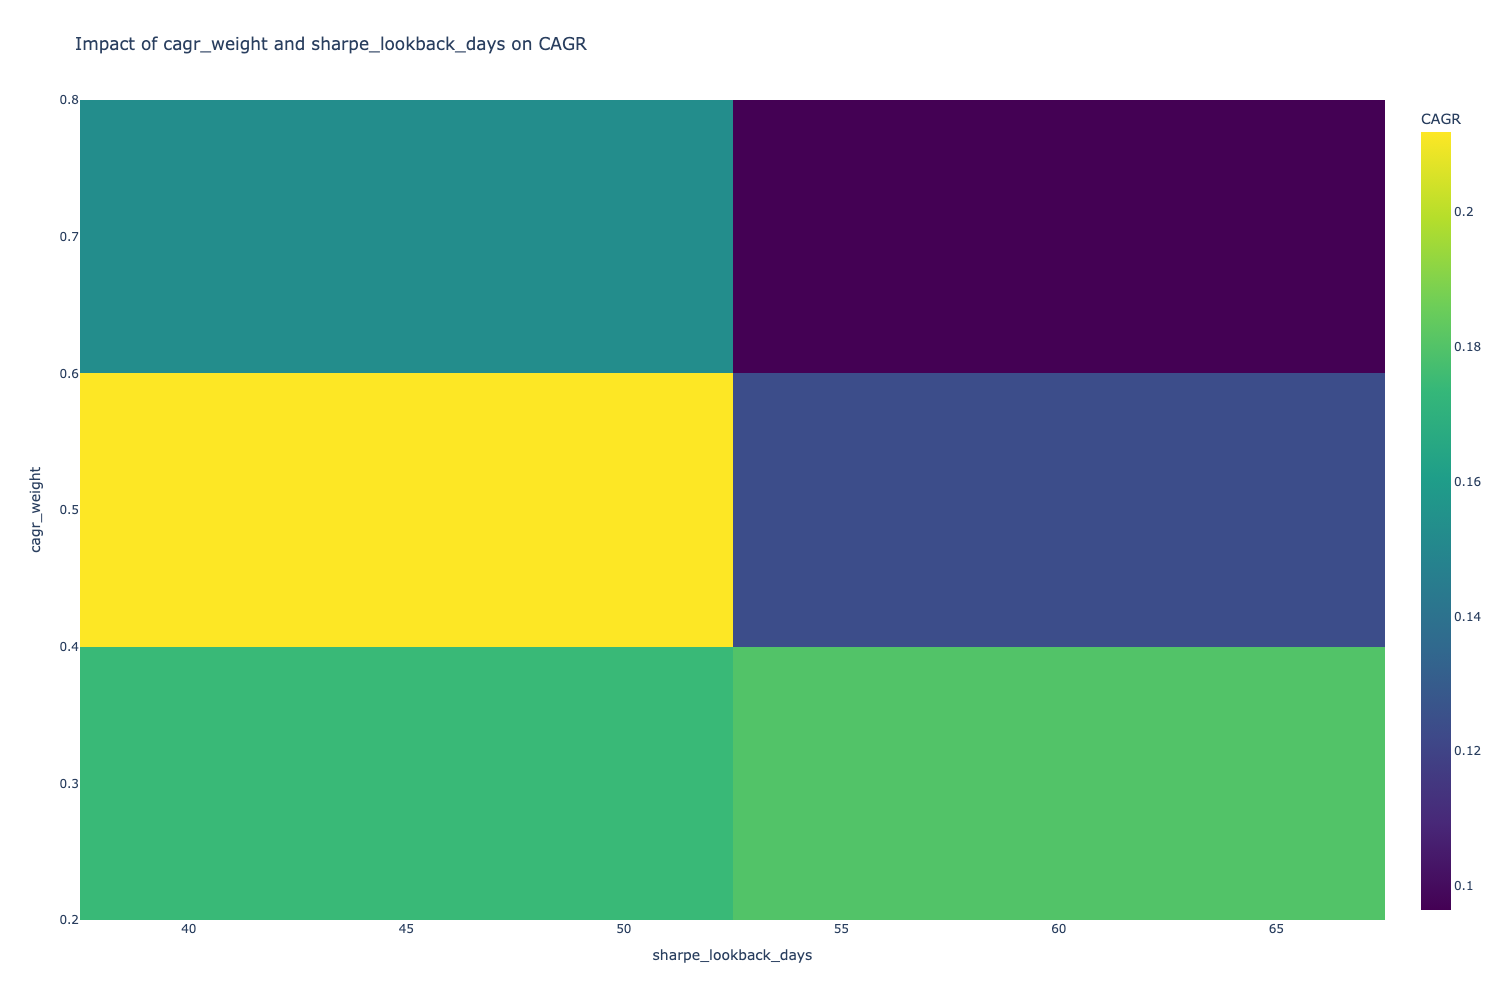

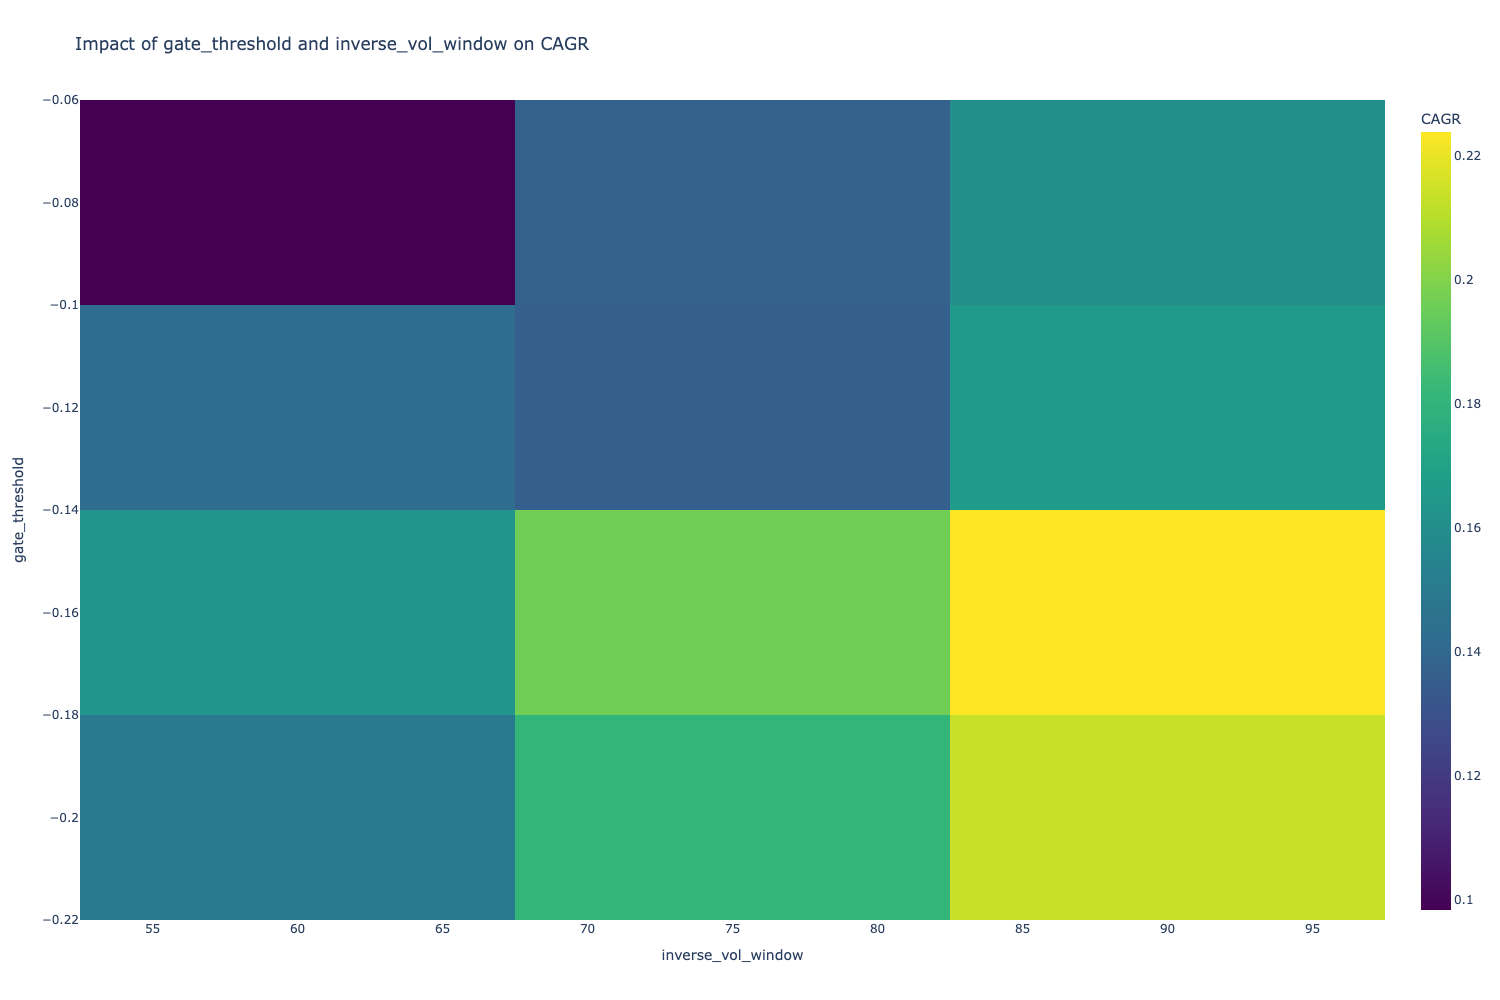

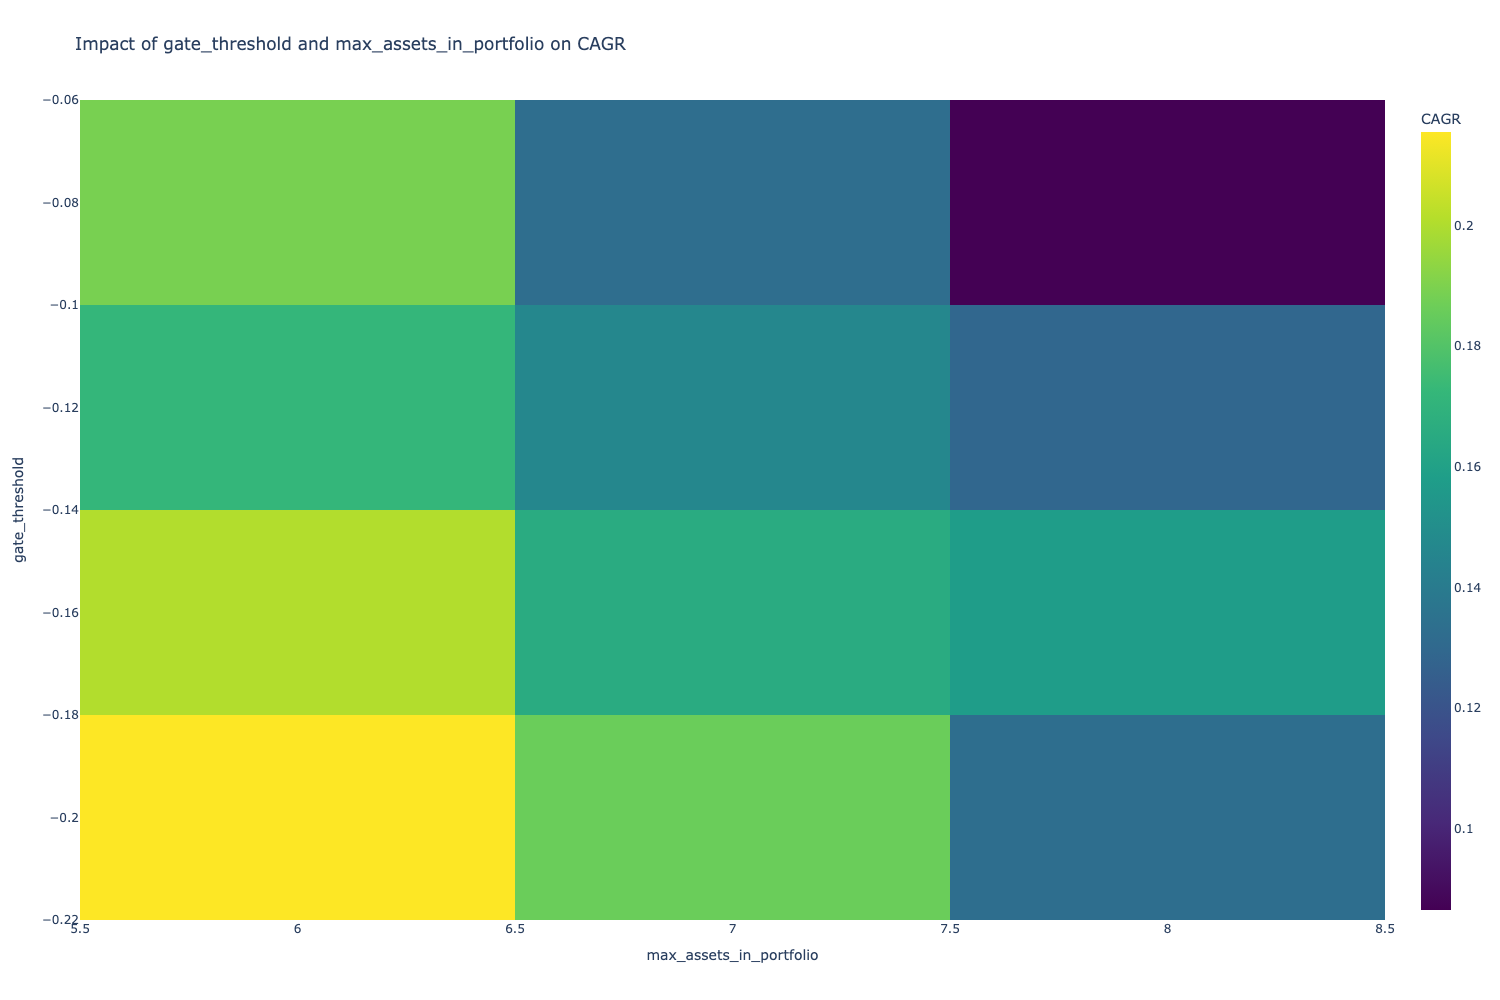

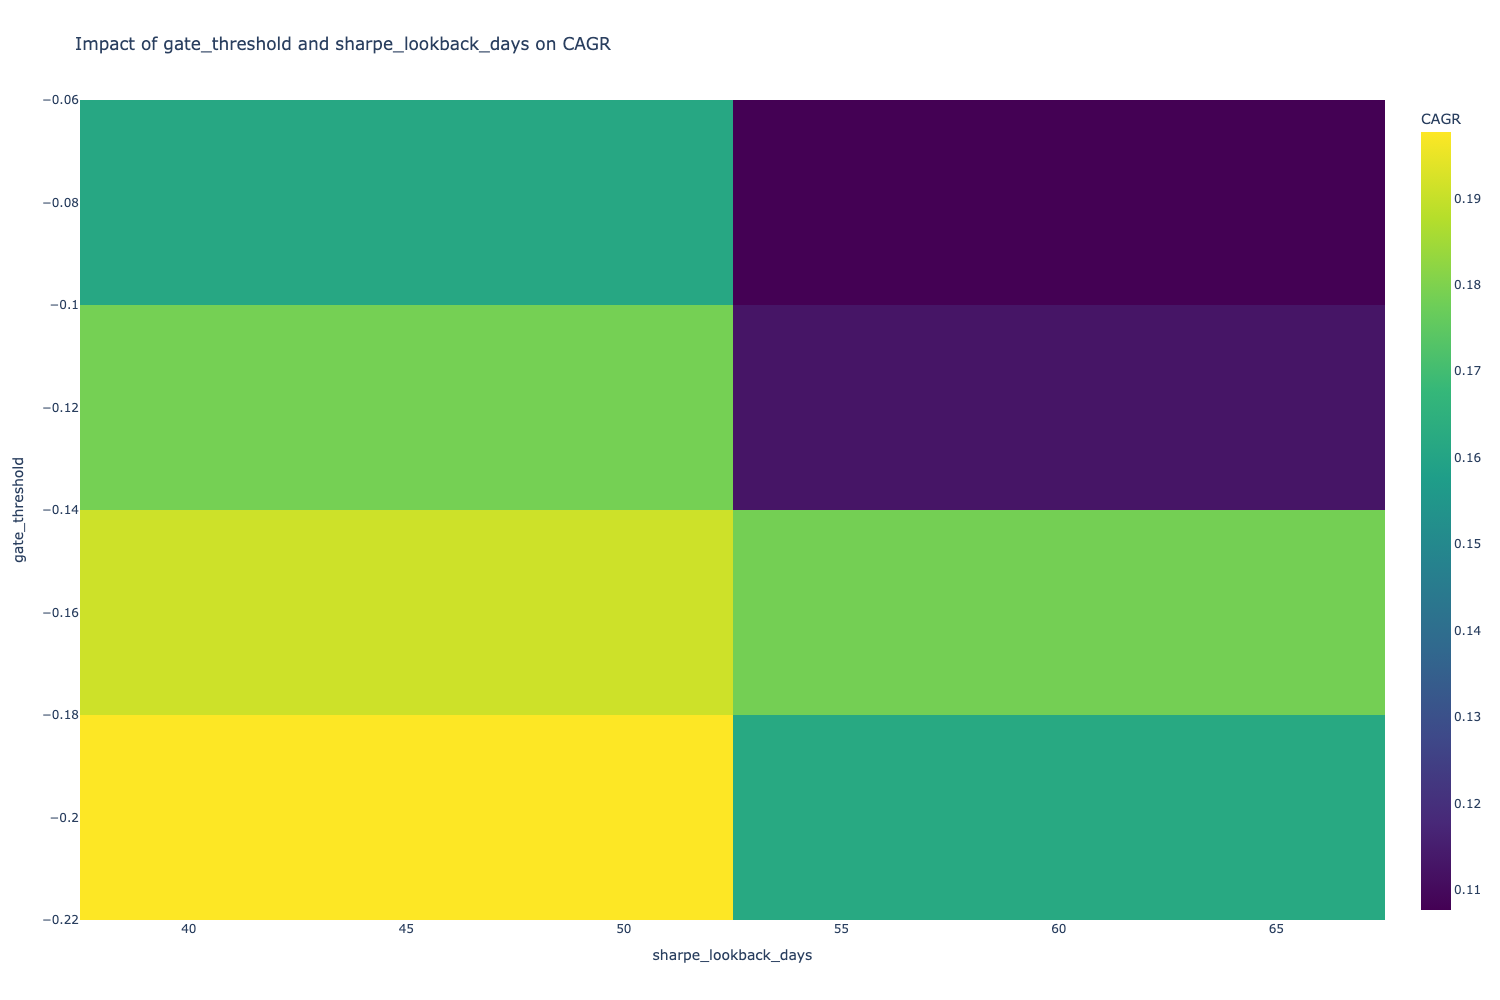

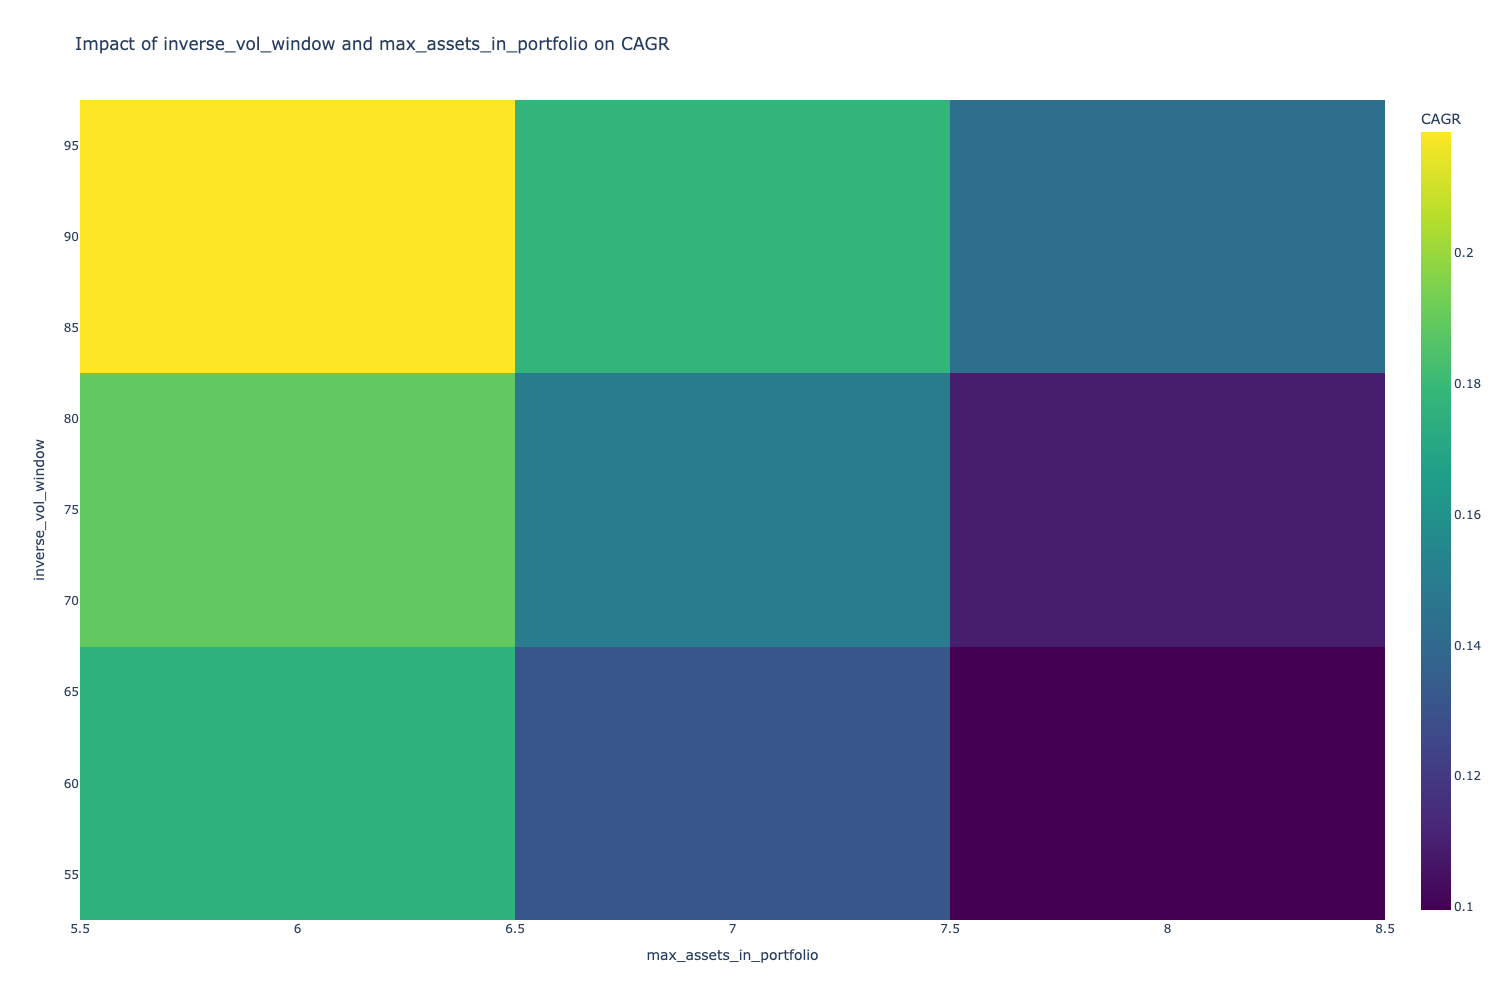

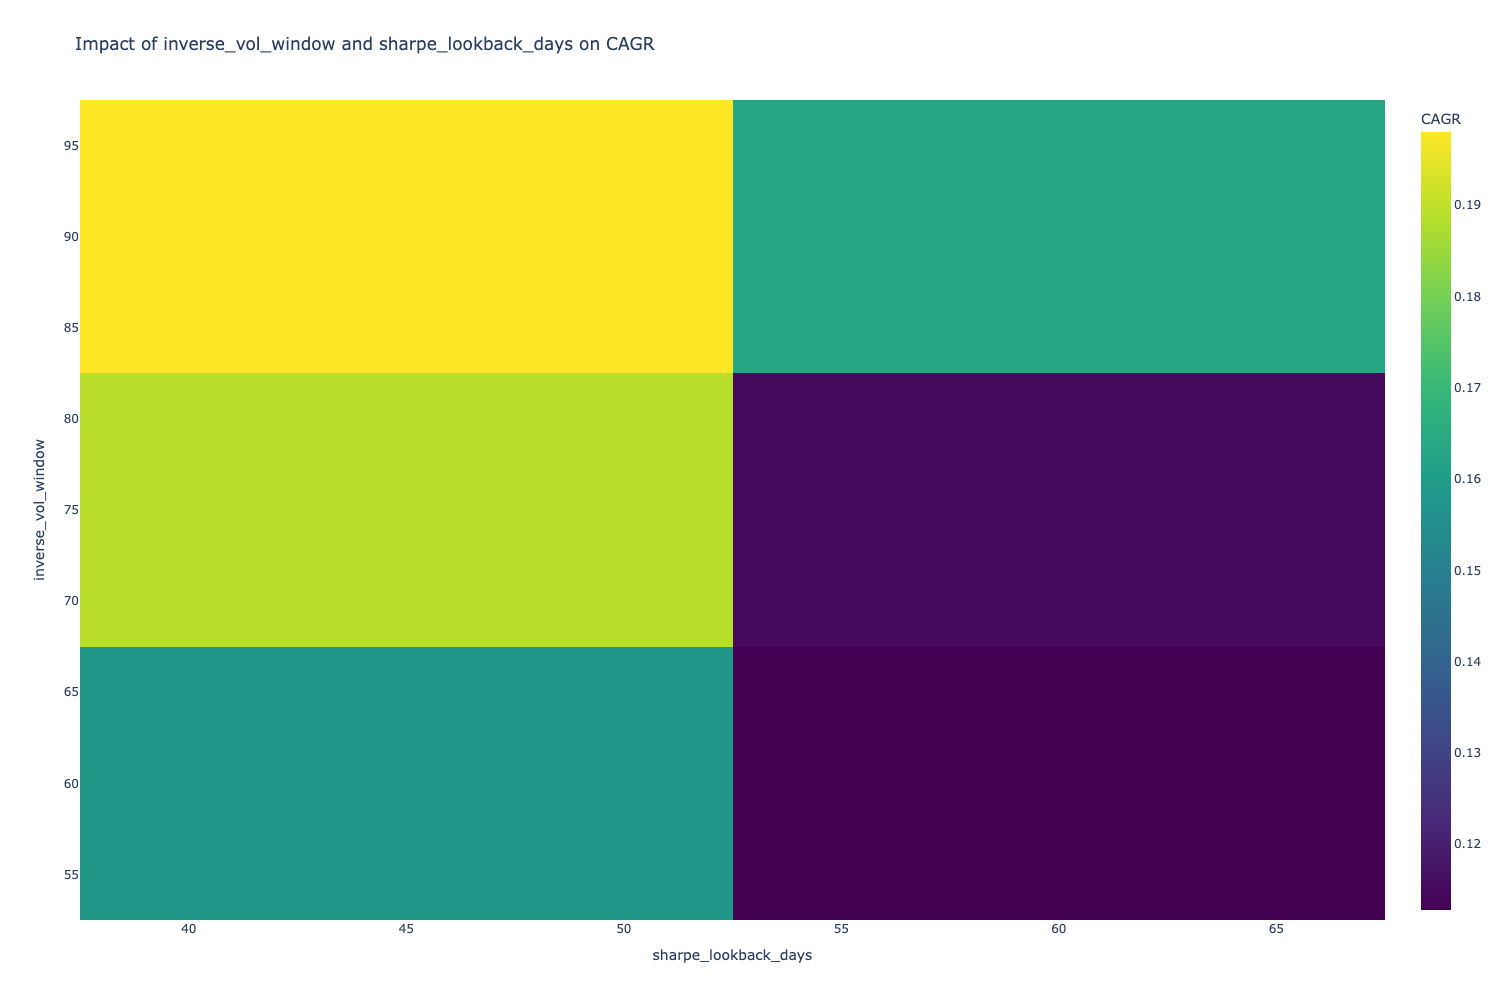

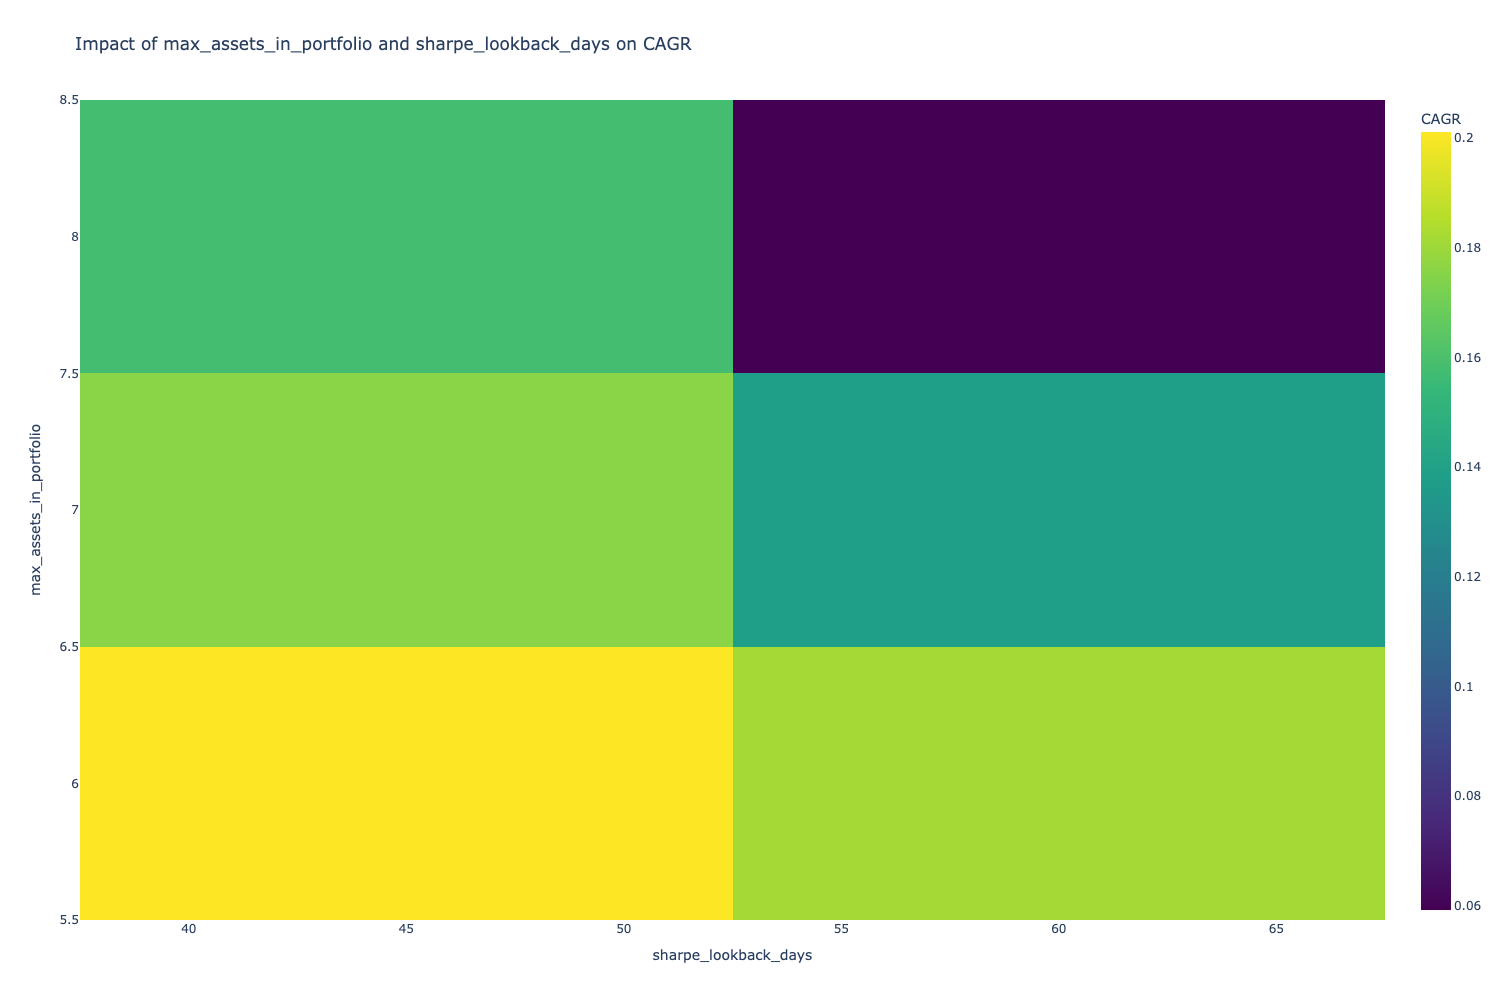

In [16]:
import plotly.graph_objects as go
import numpy as np

def create_heatmap(df, param1, param2, metric):
    # Create pivot table
    pivot = df.pivot_table(
        values=metric, 
        index=param1,
        columns=param2,
        aggfunc="mean"
    )
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='Viridis',
        colorbar=dict(title=metric)
    ))
    
    fig.update_layout(
        title=f'Impact of {param1} and {param2} on {metric}',
        xaxis_title=param2,
        yaxis_title=param1
    )
    
    return fig

# All parameter pairs, not just consecutive ones - the consecutive-only loop skipped
# hold x softband entirely.
from itertools import combinations

param_pairs = list(combinations(parameter_names, 2))

for param1, param2 in param_pairs:
    fig = create_heatmap(parameter_df, param1, param2, metric=analysis_metric)
    fig.show()

## Cluster analysis

cluster      CAGR                              Sharpe                      \
               mean       min       max count      mean       min       max   
0       0  0.180325  0.105244  0.252667    21  1.730477  1.068013  2.393617   
1       1  0.199838  0.110469  0.263722    24  1.788579  1.106637  2.597481   
2       2  0.170641  0.001101  0.277856    26  2.127088  0.061112  3.075510   
3       3  0.146965  0.072214  0.221627    15  1.117109  0.588821  1.779279   
4       4  0.084652  0.009729  0.182506    21  0.855544  0.155360  1.796389   

     Max DD                      
       mean       min       max  
0 -0.033449 -0.040746 -0.018635  
1 -0.040253 -0.054226 -0.018419  
2 -0.029017 -0.071351 -0.016555  
3 -0.049335 -0.061834 -0.033806  
4 -0.053041 -0.060488 -0.042541

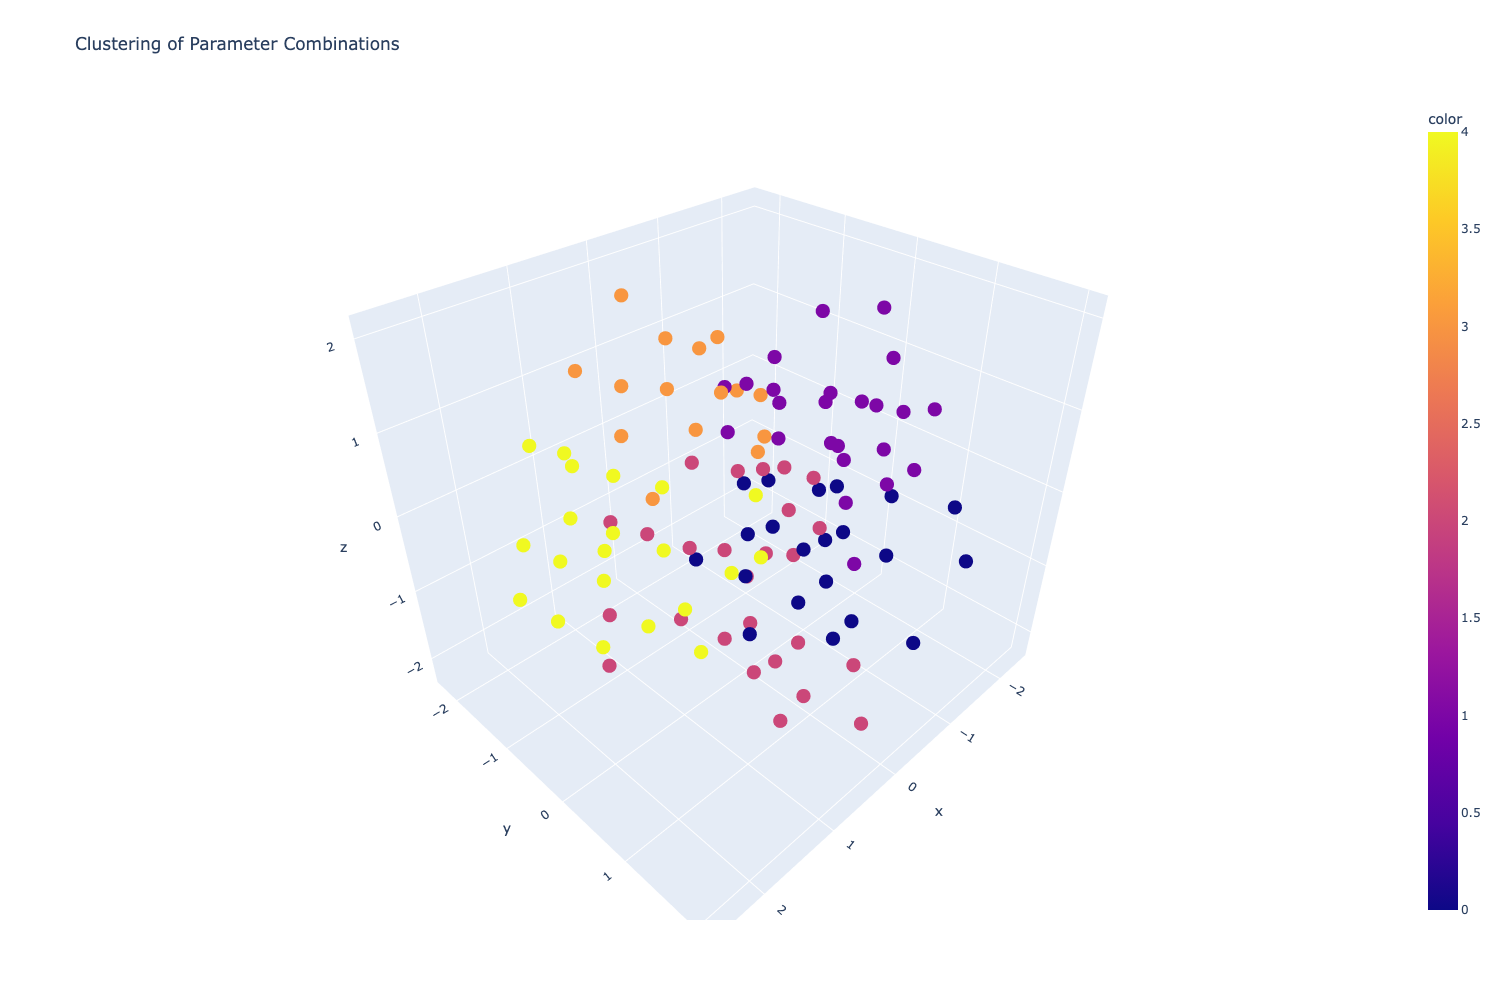

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Select features for clustering
features = parameter_names
X = parameter_df[features]

# Convert categorical values to numeric
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering (determine optimal k separately)
kmeans = KMeans(n_clusters=5, random_state=42)
parameter_df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze performance by cluster
cluster_perf = parameter_df.groupby('cluster').agg({
    'CAGR': ['mean', 'min', 'max', 'count'],
    'Sharpe': ['mean', 'min', 'max'],
    'Max DD': ['mean', 'min', 'max']
}).reset_index()

display(cluster_perf)

# Visualize clusters in 3D space (using first 3 PCA components)
from sklearn.decomposition import PCA

try:
    pca = PCA(n_components=3)
    components = pca.fit_transform(X_scaled)

    fig = px.scatter_3d(
        x=components[:, 0],
        y=components[:, 1],
        z=components[:, 2],
        color=parameter_df['cluster'],
        hover_data={'Sharpe': parameter_df['Sharpe'], 'CAGR': parameter_df['CAGR']},
        title='Clustering of Parameter Combinations'
    )
    fig.show()
except ValueError as e:
    print(f"Error in PCA: {e}")
    print("PCA failed, possibly due to too few features or singular matrix.")
    # Handle the error as needed

## Parallel coordinates plot

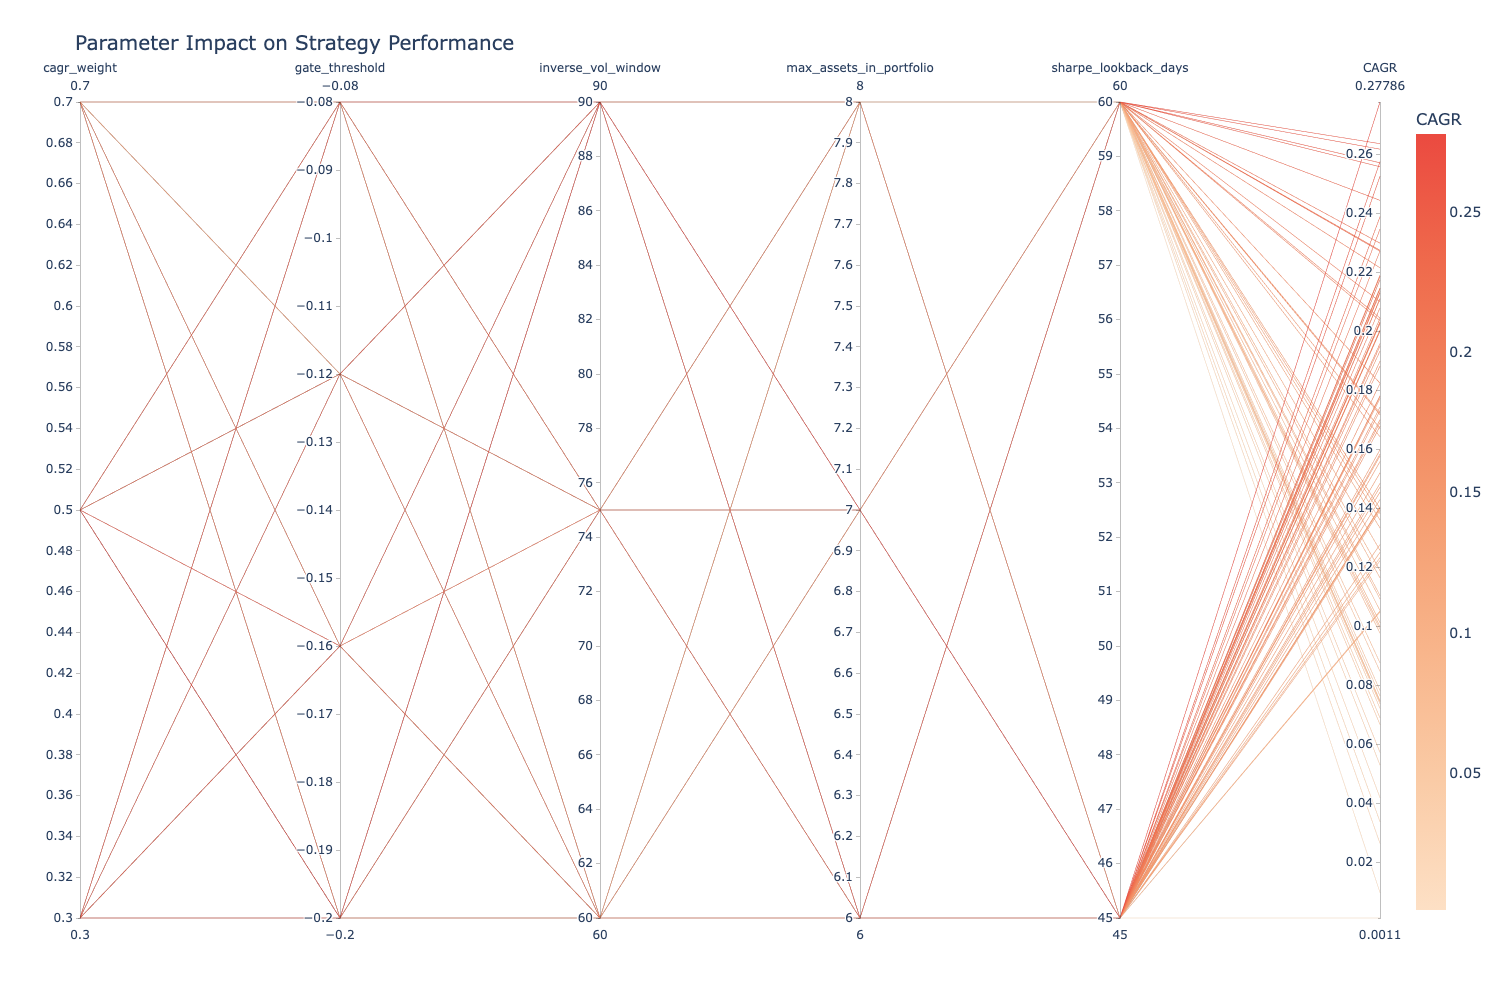

In [18]:
import plotly.express as px

# Extract top results (e.g., top 50)
top_results = parameter_df.head(50)

dimensions = parameter_names + [analysis_metric]

# Create parallel coordinates plot
fig = px.parallel_coordinates(
    parameter_df,
    dimensions=dimensions,
    color=analysis_metric,
    color_continuous_scale=px.colors.sequential.Peach,
    title='Parameter Impact on Strategy Performance'
)


# Increase font size for axis titles, tick labels, and title
fig.update_layout(
    font=dict(size=14),  # Base font size for the whole figure
    title=dict(
        text='Parameter Impact on Strategy Performance',
        font=dict(size=20)  # Title font size
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text=analysis_metric,
            font=dict(size=16)
        ),
        tickfont=dict(size=14)
    )
)

# Parallel coordinates chart: Line width not supported
# https://github.com/plotly/plotly.js/issues/2573

fig.show()

# The best candidate equity curve

The best result found for <function optimise_profit at 0x12a5b31c0> was <GridSearchResult
  #37, cagr_weight=0.5, gate_threshold=-0.2, inverse_vol_window=90, max_assets_in_portfolio=7, sharpe_lookback_days=45
  CAGR: 28.00%, Sharpe: 2.57, Sortino: 4.46, Max drawdown:-3.00%
>


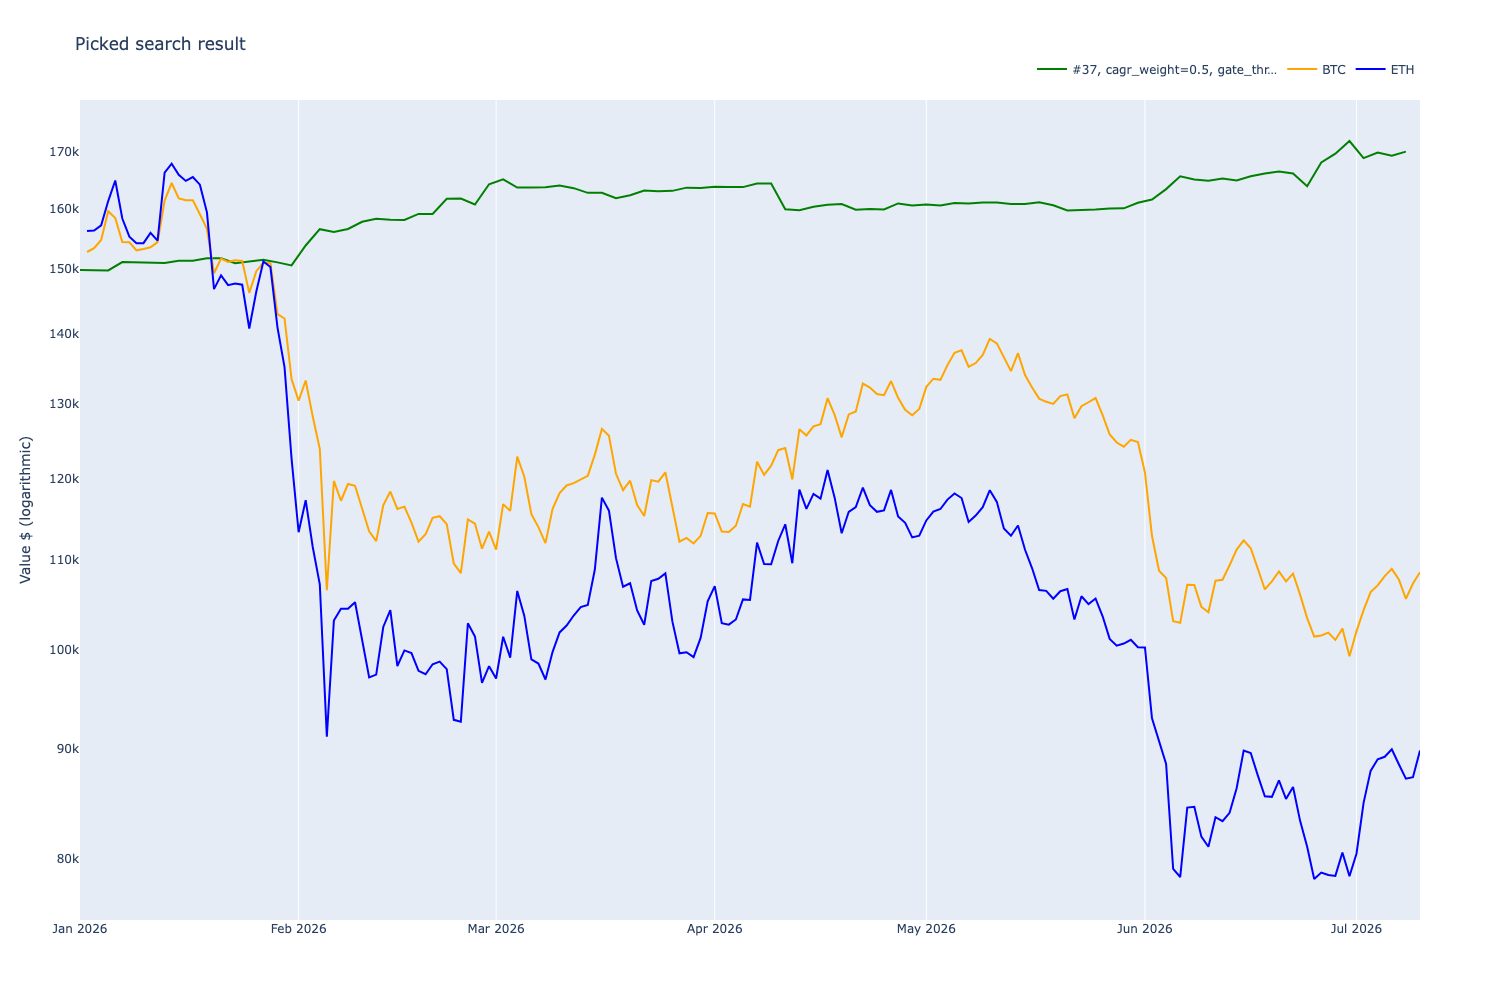

In [19]:
from tradeexecutor.visual.grid_search import visualise_single_grid_search_result_benchmark

# GridSearchResult instance that gave the best performance
best_pick = next(result.result for result in optimiser_result.results if not result.filtered)
state = best_pick.hydrate_state()

print(f"The best result found for {search_func} was {best_pick}")

fig = visualise_single_grid_search_result_benchmark(
    best_pick, 
    strategy_universe, 
    initial_cash=Parameters.initial_cash,
    log_y=True,
)
fig.show()

# Portfolio performance (best pick)

- Compare buy and hold against our best performance

In [20]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

returns = best_pick.returns

df = compare_strategy_backtest_to_multiple_assets(
    state=state,
    strategy_universe=strategy_universe,
    returns=returns,
    display=True,
    asset_count=3,
)
display(df)

,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,49.0%,98.0%,98.0%
Cumulative Return,13.46%,-31.79%,-44.56%
CAGR﹪,27.79%,-52.42%,-68.18%
Sharpe,2.57,-1.28,-1.43
Prob. Sharpe Ratio,97.05%,17.96%,15.34%
Smart Sharpe,2.53,-1.25,-1.4
Sortino,4.46,-1.72,-1.93


# Trade summary (best pick)

- Show statistics about the made trades

In [21]:
summary = best_pick.summary
display(summary.to_dataframe())

,0
Trading period length,186 days 0 hours
Trading start,None
Trading end,None
Return %,13.35%
Annualised return %,26.20%
Cash at start,"$150,000.00"
Value at end,"$170,024.28"
Time in market,0.00%
Time in market volatile,0.00%
Trade volume,"$5,678,216.09"


# Trading pair performance breakdown

- Show breakdown of different pairs on the best result

In [22]:
from tradeexecutor.analysis.multipair import analyse_multipair
from tradeexecutor.analysis.multipair import format_multipair_summary

# Zero-duration positions: opened and closed inside the same decision cycle.
#
# `analyse_multipair()` asserts every position has a positive duration, so one of these aborts the
# whole analysis. They are a real artefact of a 2-day cadence, not a reporting nuisance: the
# strategy opened a vault position and unwound it before the next decision point, paying the 10 BPS
# exit fee for no holding period at all. Report them, then run the analysis on what remains.
zero_duration = [
    p for p in state.portfolio.get_all_positions()
    if p.closed_at is not None and p.opened_at is not None and p.closed_at <= p.opened_at
]

if zero_duration:
    print(f"{len(zero_duration)} position(s) opened and closed within one cycle:")
    display(pd.DataFrame([{
        "Vault": p.pair.base.token_symbol,
        "Opened": p.opened_at,
        "Closed": p.closed_at,
        "Realised profit USD": float(p.get_realised_profit_usd() or 0.0),
        "Trades": p.get_trade_count(),
    } for p in zero_duration]).style.format({"Realised profit USD": "${:,.2f}"}).set_caption(
        "Positions with no holding period - they pay the exit fee and cannot earn vault yield"
    ))
    print("These are excluded from the multipair summary below because "
          "analyse_multipair() asserts on them.")

try:
    multipair_summary = analyse_multipair(state)
    display(format_multipair_summary(multipair_summary))
except AssertionError as exc:
    print(f"Multipair summary unavailable: {exc}")
    print("This is the zero-duration position issue above, not a data problem.")


,Trading pair,Positions,Trades,Total return %,Total PnL USD,Best,Worst,Avg,Median,Volume,Wins,Losses,Take profits,Stop losses,Trailing stop losses,Volatility
2,Octavious Maximus,4,18,52.40%,"1,977.70",61.88%,-4.55%,13.10%,-2.47%,"41,666.94",1,3,0,0,0,28.18%
18,songer1993.hl,1,3,24.30%,"1,246.41",24.30%,24.30%,24.30%,24.30%,"11,502.99",1,0,0,0,0,0.00%
10,Didibaba,3,8,16.99%,511.75,27.16%,-8.28%,5.66%,-1.89%,"25,600.50",1,2,0,0,0,15.42%
23,Alphadhad X,2,5,9.54%,311.51,9.64%,-0.10%,4.77%,4.77%,"13,390.84",1,1,0,0,0,4.87%
1,Goon Edging,5,37,9.43%,"7,984.70",7.48%,-2.06%,1.89%,-0.57%,"234,942.76",2,3,0,0,0,4.20%
22,HBS Bitcoin Volatility Engine,2,5,8.06%,641.78,5.39%,2.67%,4.03%,4.03%,"33,031.96",2,0,0,0,0,1.36%
20,Hyperliquidity Provider (HLP),6,18,5.80%,"2,826.79",6.26%,-0.10%,0.97%,-0.10%,"635,714.38",1,5,0,0,0,2.37%
0,22Cap,2,41,4.76%,"5,174.87",4.29%,0.46%,2.38%,2.38%,"273,607.80",2,0,0,0,0,1.92%
5,Mad Scientists,1,6,3.56%,692.45,3.56%,3.56%,3.56%,3.56%,"20,273.69",1,0,0,0,0,0.00%
13,-VectorZero-,6,18,3.45%,658.22,5.41%,-0.91%,0.57%,-0.10%,"297,990.34",1,5,0,0,0,2.19%


# Best positions

- Find positions that made most profit for the leading backtest

In [23]:
profit_by_position = [(p.get_realised_profit_usd(), p) for p in state.portfolio.get_all_positions()]
profit_by_position.sort(key=lambda t: t[0] or -999_999_999, reverse=True)

data = []

for profit, p in profit_by_position[0:5]:
    data.append({
        "Profit USD": profit,
        "Pair": p.pair.get_ticker(),
        "Position id": p.position_id,
        "Opened": p.opened_at,
        "Closed": p.closed_at,
        "Duration": p.closed_at - p.opened_at if p.closed_at else "(still open)",
        "Open price": p.get_opening_price(),
        "Close price": p.get_closing_price(),
        "Trades": p.get_trade_count(),
        "Price gain %": (p.get_closing_price() - p.get_opening_price()) / p.get_opening_price() * 100,
        "Weight at open %": p.get_capital_tied_at_open_pct() * 100,
    })

df = pd.DataFrame(data)
display(df)

,Profit USD,Pair,Position id,Opened,Closed,Duration,Open price,Close price,Trades,Price gain %,Weight at open %
0,3612.865385,pmalt-USDC,23,2026-01-23,2026-05-21,"118 days, 0:00:00",10.693423,11.255627,43,5.257469,4.572299
1,3069.533914,Hyperliqui-USDC,21,2026-01-23,2026-02-02,"10 days, 0:00:00",2.453729,2.607270,4,6.257443,32.340000
2,2730.492286,Goon Edgin-USDC,77,2026-05-29,NaT,(still open),1.432827,1.754416,17,22.444313,10.779318
3,2629.932368,Octavious -USDC,82,2026-06-02,2026-06-10,"8 days, 0:00:00",2.331916,3.521907,4,51.030625,2.629308
4,2419.561158,Goon Edgin-USDC,28,2026-02-02,2026-03-08,"34 days, 0:00:00",1.509088,1.416280,13,-6.149968,15.831567


# Rolling sharpe

- The rolling sharpe ratio of the best pick

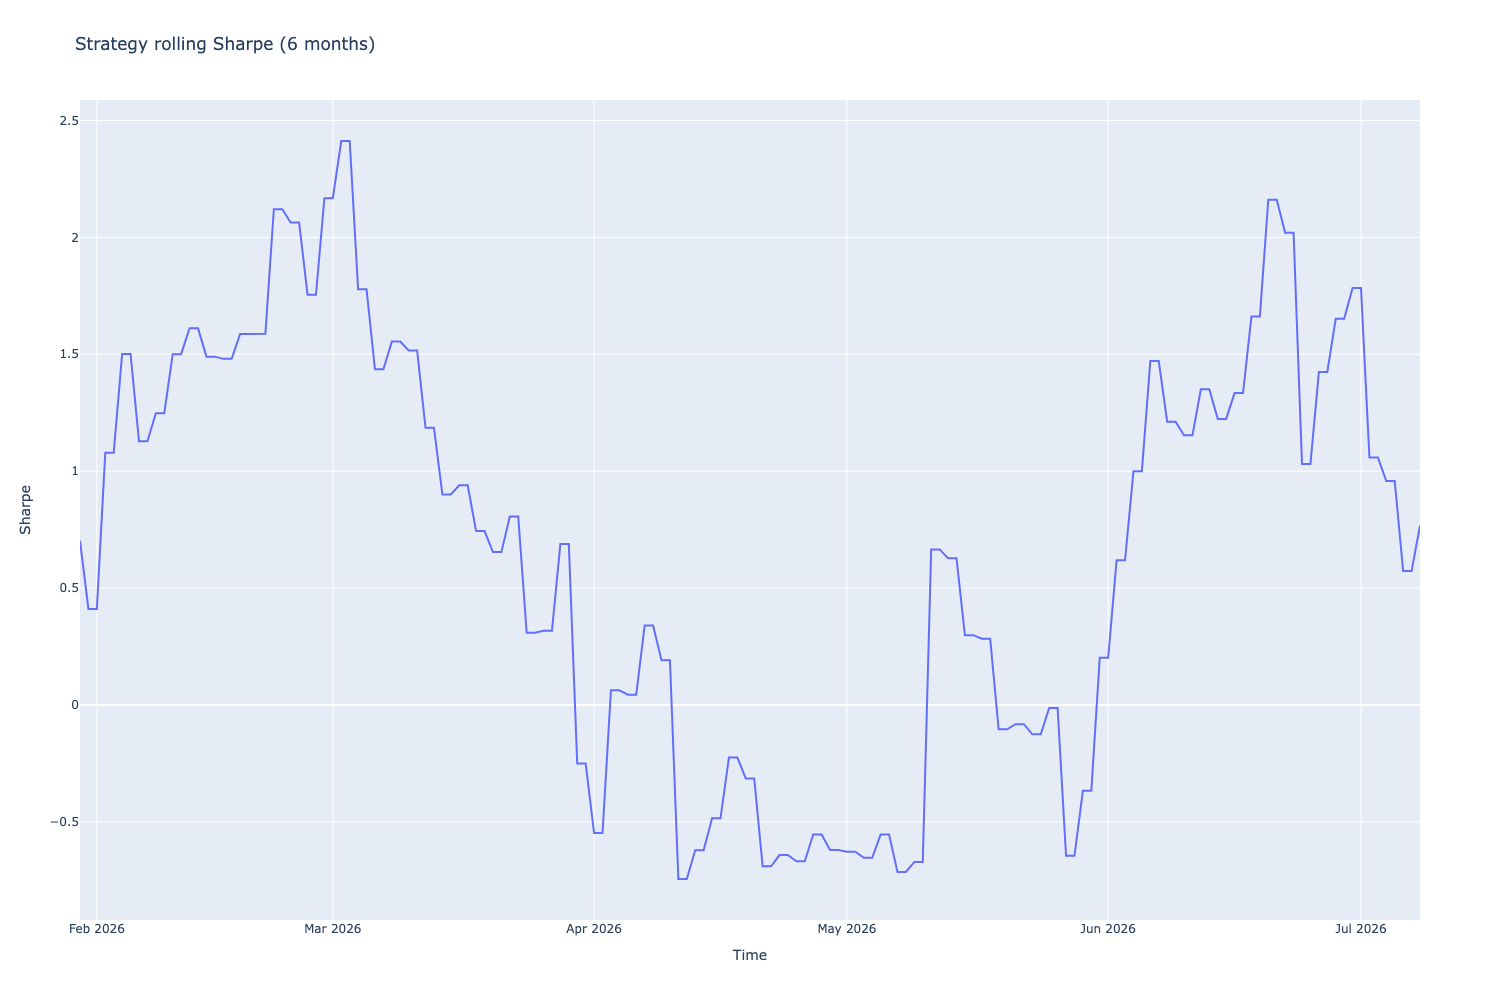

In [24]:
import plotly.express as px

from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.visual.equity_curve import calculate_rolling_sharpe

# A 180-day window over a ~190-day backtest leaves ~10 points; 30 days is readable.
rolling_sharpe = calculate_rolling_sharpe(
    returns,
    freq="D",
    periods=30,
)

fig = px.line(rolling_sharpe, title='Strategy rolling Sharpe (6 months)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Sharpe")
fig.update_xaxes(title="Time")
fig.show()

# Data diagnosics

- Some example code to track down issues with data


In [25]:
# data = [{"Timestamp": s.calculated_at, "Equity": s.net_asset_value} for s in state.stats.portfolio]
# df = pd.DataFrame(data)
# df = df.set_index("Timestamp")

# with pd.option_context('display.min_rows', 50, "display.max_rows", 50):
#     display(df)

In [26]:
# for t in state.portfolio.get_all_trades():
#     if t.executed_at.date() == datetime.date(2023, 12, 29):
#         print(t, t.pair, t.get_value())

In [27]:
# import plotly.graph_objects as go

# pair_desc = (ChainId.ethereum, "uniswap-v3", "WBTC", "USDC", 0.0005)
# pair = strategy_universe.get_pair_by_human_description(pair_desc)
# df = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)


# fig = go.Figure(data=go.Ohlc(x=df.timestamp,
#                     open=df.open,
#                     high=df.high,
#                     low=df.low,
#                     close=df.close))
# fig.show()

# with pd.option_context('display.min_rows', 5000, "display.max_rows", 5000, 'display.float_format', lambda x: f'{x:.6f}'):
#     display(df)